In [1]:
from google.colab import files

uploaded = files.upload()

Saving sen12ms_qa_dataset.zip to sen12ms_qa_dataset.zip


In [2]:
# ============================================================
# SATQUERY — DATASET SETUP
# BLOCK 1: FIND UPLOADED FILE
# ============================================================

import os
import glob

print("=" * 70)
print("UPLOADED FILES")
print("=" * 70)

for f in glob.glob("/content/*"):
    print(f)

UPLOADED FILES
/content/sen12ms_qa_dataset.zip
/content/sample_data


In [3]:
# ============================================================
# BLOCK 2: EXTRACT DATASET
# ============================================================

import zipfile
import os

zip_files = glob.glob("/content/*.zip")

if len(zip_files) == 0:
    print("No ZIP file found.")
else:

    zip_path = zip_files[0]

    extract_dir = "/content/sen12ms"

    os.makedirs(
        extract_dir,
        exist_ok=True
    )

    print("Extracting:")
    print(zip_path)

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            extract_dir
        )

    print("\nExtraction complete.")
    print("Location:", extract_dir)

Extracting:
/content/sen12ms_qa_dataset.zip

Extraction complete.
Location: /content/sen12ms


In [4]:
# ============================================================
# BLOCK 3: INSPECT DATASET STRUCTURE
# ============================================================

import os

ROOT = "/content/sen12ms"

print("=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(ROOT):

    level = root.replace(ROOT, "").count(os.sep)

    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:

        print(
            f"{indent}  {file}"
        )

DATASET STRUCTURE
sen12ms/
  qa.parquet
  metadata.parquet
  qa_unified.parquet
  manifest.parquet
  sen12ms_qa_final.parquet
  s2/
    ROIs1158_spring_s2_1_p102.tif
    ROIs1158_spring_s2_1_p101.tif
    ROIs1158_spring_s2_1_p100.tif
  s1/
    ROIs1158_spring_s1_1_p100.tif
    ROIs1158_spring_s1_1_p102.tif
    ROIs1158_spring_s1_1_p101.tif


SEN12MS DATASET

S1 files: 3
  ROIs1158_spring_s1_1_p100.tif
  ROIs1158_spring_s1_1_p101.tif
  ROIs1158_spring_s1_1_p102.tif

S2 files: 3
  ROIs1158_spring_s2_1_p100.tif
  ROIs1158_spring_s2_1_p101.tif
  ROIs1158_spring_s2_1_p102.tif

Common paired patches: 3
Patch IDs: ['p100', 'p101', 'p102']

S1 ↔ S2 DATASET VERIFICATION

----------------------------------------------------------------------
PATCH: p100
 S1 shape : (2, 256, 256)
 S1 CRS   : EPSG:32737
 S1 bounds: BoundingBox(left=390772.3389928384, bottom=8111622.836060452, right=393332.3389928384, top=8114182.836060452)
 S2 shape : (13, 256, 256)
 S2 CRS   : EPSG:32737
 S2 bounds: BoundingBox(left=390772.3389928384, bottom=8111622.836060452, right=393332.3389928384, top=8114182.836060452)
 Aligned  : True

----------------------------------------------------------------------
PATCH: p101
 S1 shape : (2, 256, 256)
 S1 CRS   : EPSG:32737
 S1 bounds: BoundingBox(left=392052.3389928384, bottom=8111622.836060452, right=394612.3389928384

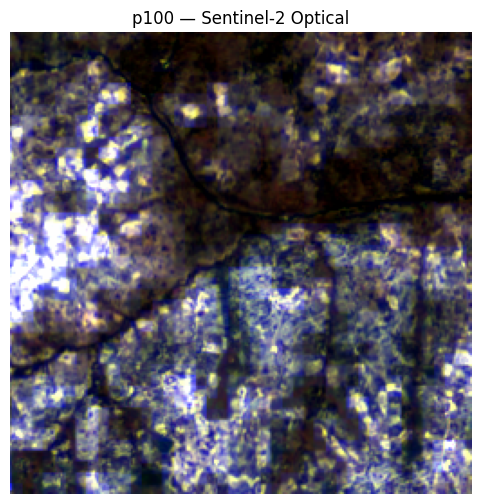

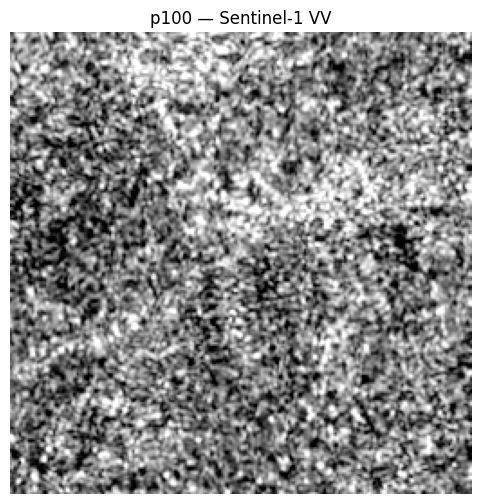

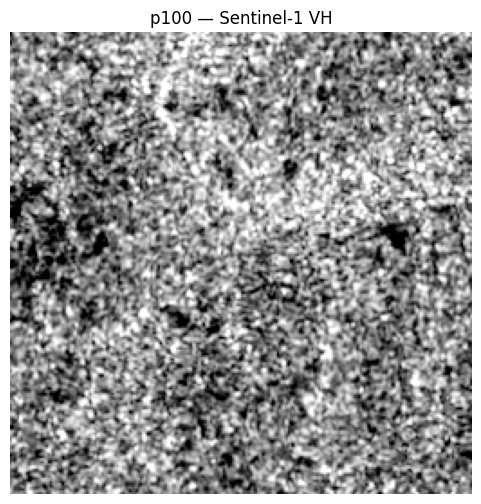

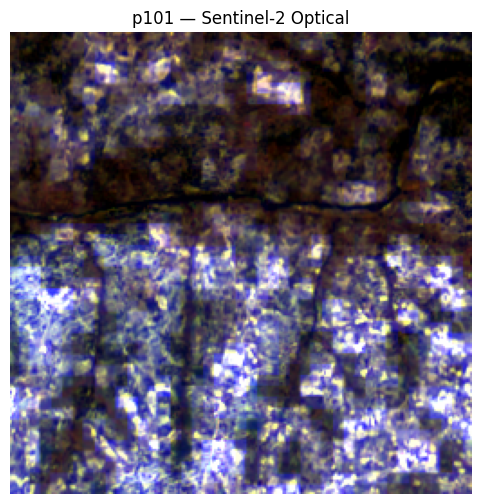

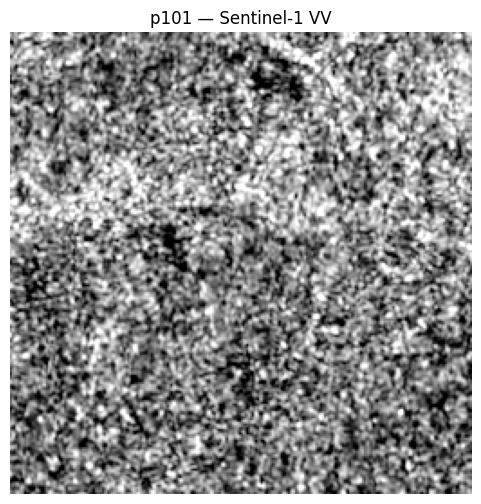

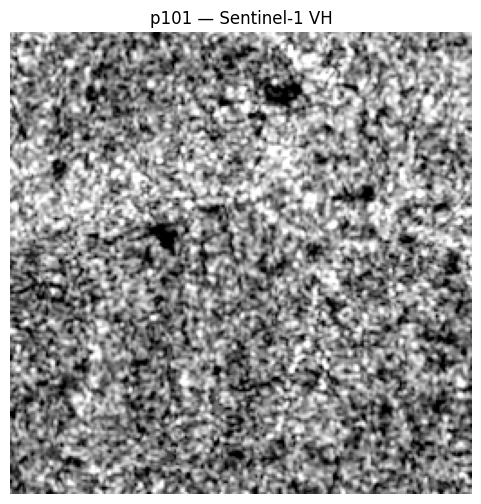


BIGEARTHNET-STYLE METADATA CREATED
Shape: (3, 8)

Columns:
 - patch_id
 - labels
 - split
 - country
 - s1_name
 - s2v1_name
 - contains_seasonal_snow
 - contains_cloud_or_shadow


,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
0,p100,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
1,p101,[],train,unknown,ROIs1158_spring_s1_1_p101,ROIs1158_spring_s2_1_p101,False,False
2,p102,[],train,unknown,ROIs1158_spring_s1_1_p102,ROIs1158_spring_s2_1_p102,False,False



Saved: /content/sen12ms/metadata.parquet

FINAL DATASET INTEGRITY CHECK

PATCH: p100
  S1: OK
  S2: OK
  S1 shape : (2, 256, 256)
  S2 shape : (13, 256, 256)
  CRS match : True
  Bounds match : True

PATCH: p101
  S1: OK
  S2: OK
  S1 shape : (2, 256, 256)
  S2 shape : (13, 256, 256)
  CRS match : True
  Bounds match : True

PATCH: p102
  S1: OK
  S2: OK
  S1 shape : (2, 256, 256)
  S2 shape : (13, 256, 256)
  CRS match : True
  Bounds match : True

QA DATASET CREATED
Number of QA pairs: 30
Number of patches: 3

Questions per patch:
patch_id
p100    10
p101    10
p102    10
dtype: int64

Question types:
question_type
availability    6
band_count      6
metadata        6
datatype        6
alignment       3
spatial_size    3
Name: count, dtype: int64


,patch_id,question,answer,question_type,modality
0,p100,Is Sentinel-1 SAR imagery available for this p...,Yes,availability,S1
1,p100,Is Sentinel-2 optical imagery available for th...,Yes,availability,S2
2,p100,Are Sentinel-1 and Sentinel-2 images spatially...,Yes,alignment,S1+S2
3,p100,How many Sentinel-1 bands are available?,2,band_count,S1
4,p100,How many Sentinel-2 bands are available?,13,band_count,S2
5,p100,What is the spatial size of the patch?,256 x 256 pixels,spatial_size,S1+S2
6,p100,What is the data type of the Sentinel-1 imagery?,float32,datatype,S1
7,p100,What is the data type of the Sentinel-2 imagery?,float32,datatype,S2
8,p100,Does this patch contain seasonal snow?,No,metadata,metadata
9,p100,Does this patch contain cloud or shadow?,No,metadata,metadata



Saved: /content/sen12ms/qa.parquet

Visual QA created:
question_type
visual_vegetation      3
visual_water           3
vegetation_coverage    3
sar_backscatter        3
spectral_variation     3
ndvi                   3
vegetation_fraction    3
water_fraction         3
Name: count, dtype: int64

FINAL SEN12MS-QA DATASET SAVED
Patches : 3
QA pairs: 54

Answer dtype:
object

Saved to:
/content/sen12ms/sen12ms_qa_final.parquet

QA distribution:
question_type
availability           6
band_count             6
metadata               6
datatype               6
alignment              3
spatial_size           3
visual_vegetation      3
visual_water           3
vegetation_coverage    3
sar_backscatter        3
spectral_variation     3
ndvi                   3
vegetation_fraction    3
water_fraction         3
Name: count, dtype: int64


,patch_id,question,answer,question_type,modality,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
0,p100,Is Sentinel-1 SAR imagery available for this p...,Yes,availability,S1,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
1,p100,Is Sentinel-2 optical imagery available for th...,Yes,availability,S2,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
2,p100,Are Sentinel-1 and Sentinel-2 images spatially...,Yes,alignment,S1+S2,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
3,p100,How many Sentinel-1 bands are available?,2,band_count,S1,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
4,p100,How many Sentinel-2 bands are available?,13,band_count,S2,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
5,p100,What is the spatial size of the patch?,256 x 256 pixels,spatial_size,S1+S2,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
6,p100,What is the data type of the Sentinel-1 imagery?,float32,datatype,S1,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
7,p100,What is the data type of the Sentinel-2 imagery?,float32,datatype,S2,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
8,p100,Does this patch contain seasonal snow?,No,metadata,metadata,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False
9,p100,Does this patch contain cloud or shadow?,No,metadata,metadata,[],train,unknown,ROIs1158_spring_s1_1_p100,ROIs1158_spring_s2_1_p100,False,False



FINAL DATASET VALIDATION

Required columns:
  patch_id                       OK
  question                       OK
  answer                         OK
  question_type                  OK
  modality                       OK
  labels                         OK
  split                          OK
  country                        OK
  s1_name                        OK
  s2v1_name                      OK
  contains_seasonal_snow         OK
  contains_cloud_or_shadow       OK

Patch count:
3

QA count:
54

Missing answers:
0

Missing patch IDs:
0

DATASET READY FOR SATQUERY MODEL PIPELINE

Next layer:
User Image/TIFF + Query
        ↓
Agentic Router


In [5]:
# ============================================================
# SATQUERY — SEN12MS DATASET PREPARATION
# Everything BEFORE Agentic Routing
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import rasterio
import torch
import matplotlib.pyplot as plt


# ============================================================
# 1. DATASET PATHS
# ============================================================

BASE = "/content/sen12ms"

S1_DIR = os.path.join(BASE, "s1")
S2_DIR = os.path.join(BASE, "s2")

METADATA_PATH = os.path.join(BASE, "metadata.parquet")
QA_PATH = os.path.join(BASE, "qa.parquet")
QA_UNIFIED_PATH = os.path.join(BASE, "qa_unified.parquet")
FINAL_QA_PATH = os.path.join(BASE, "sen12ms_qa_final.parquet")


# ============================================================
# 2. FIND S1 AND S2 TIFF FILES
# ============================================================

s1_files = sorted(glob.glob(os.path.join(S1_DIR, "*.tif")))
s2_files = sorted(glob.glob(os.path.join(S2_DIR, "*.tif")))

print("=" * 70)
print("SEN12MS DATASET")
print("=" * 70)

print("\nS1 files:", len(s1_files))
for f in s1_files:
    print(" ", os.path.basename(f))

print("\nS2 files:", len(s2_files))
for f in s2_files:
    print(" ", os.path.basename(f))


# ============================================================
# 3. MAP S1 ↔ S2 USING PATCH ID
# ============================================================

def get_patch_id(filename):
    name = os.path.basename(filename)
    return name.split("_")[-1].replace(".tif", "")


s1_map = {
    get_patch_id(f): f
    for f in s1_files
}

s2_map = {
    get_patch_id(f): f
    for f in s2_files
}

common_patches = sorted(
    set(s1_map.keys()) & set(s2_map.keys())
)

print("\nCommon paired patches:", len(common_patches))
print("Patch IDs:", common_patches)


# ============================================================
# 4. VERIFY S1 ↔ S2 GEOMETRIC ALIGNMENT
# ============================================================

print("\n" + "=" * 70)
print("S1 ↔ S2 DATASET VERIFICATION")
print("=" * 70)

verified_pairs = []

for patch_id in common_patches:

    s1_path = s1_map[patch_id]
    s2_path = s2_map[patch_id]

    with rasterio.open(s1_path) as s1_src:
        s1_shape = (s1_src.count, s1_src.height, s1_src.width)
        s1_crs = s1_src.crs
        s1_bounds = s1_src.bounds
        s1_dtype = s1_src.dtypes

    with rasterio.open(s2_path) as s2_src:
        s2_shape = (s2_src.count, s2_src.height, s2_src.width)
        s2_crs = s2_src.crs
        s2_bounds = s2_src.bounds
        s2_dtype = s2_src.dtypes

    crs_match = s1_crs == s2_crs
    bounds_match = s1_bounds == s2_bounds
    size_match = (
        s1_shape[1:] == s2_shape[1:]
    )

    print("\n" + "-" * 70)
    print("PATCH:", patch_id)

    print(" S1 shape :", s1_shape)
    print(" S1 CRS   :", s1_crs)
    print(" S1 bounds:", s1_bounds)

    print(" S2 shape :", s2_shape)
    print(" S2 CRS   :", s2_crs)
    print(" S2 bounds:", s2_bounds)

    print(" Aligned  :", crs_match and bounds_match and size_match)

    if crs_match and bounds_match and size_match:
        verified_pairs.append({
            "patch_id": patch_id,
            "s1_path": s1_path,
            "s2_path": s2_path
        })


print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

print("Verified pairs:", len(verified_pairs))


# ============================================================
# 5. LOAD ONE PATCH INTO PYTORCH
# ============================================================

patch_id = "p100"

s1_path = s1_map[patch_id]
s2_path = s2_map[patch_id]

with rasterio.open(s1_path) as src:
    s1_np = src.read().astype(np.float32)

with rasterio.open(s2_path) as src:
    s2_np = src.read()

print("\n" + "=" * 70)
print("RAW PATCH")
print("=" * 70)

print("S1:")
print("shape =", s1_np.shape)
print("dtype =", s1_np.dtype)
print("min   =", s1_np.min())
print("max   =", s1_np.max())

print("\nS2:")
print("shape =", s2_np.shape)
print("dtype =", s2_np.dtype)
print("min   =", s2_np.min())
print("max   =", s2_np.max())


# ============================================================
# 6. NORMALIZE S2
# ============================================================

s2_np_float = s2_np.astype(np.float32) / 10000.0

print("\nS2 normalized:")
print("min =", s2_np_float.min())
print("max =", s2_np_float.max())


# ============================================================
# 7. CONVERT TO TORCH TENSORS
# ============================================================

s1_tensor = torch.from_numpy(s1_np)
s2_tensor = torch.from_numpy(s2_np_float)

print("\n" + "=" * 70)
print("TORCH REPRESENTATION")
print("=" * 70)

print("S1:", s1_tensor.shape)
print("S2:", s2_tensor.shape)


# ============================================================
# 8. CREATE A SMALL 2-PATCH MODEL DATASET
# ============================================================

selected_patches = ["p100", "p101"]

s1_tensors = []
s2_tensors = []

for patch_id in selected_patches:

    with rasterio.open(s1_map[patch_id]) as src:
        s1_arr = src.read().astype(np.float32)

    with rasterio.open(s2_map[patch_id]) as src:
        s2_arr = src.read().astype(np.float32)

    s2_arr = s2_arr / 10000.0

    s1_tensors.append(torch.from_numpy(s1_arr))
    s2_tensors.append(torch.from_numpy(s2_arr))


s1_batch = torch.stack(s1_tensors)
s2_batch = torch.stack(s2_tensors)

print("\n" + "=" * 70)
print("DATASET READY")
print("=" * 70)

print("S1 shape:", s1_batch.shape)
print("S2 shape:", s2_batch.shape)

print("Patch IDs:", selected_patches)

print(
    "S1 range:",
    s1_batch.min().item(),
    "→",
    s1_batch.max().item()
)

print(
    "S2 range:",
    s2_batch.min().item(),
    "→",
    s2_batch.max().item()
)


# ============================================================
# 9. VISUALIZATION HELPERS
# ============================================================

def normalize_for_display(x):

    x_min = np.percentile(x, 2)
    x_max = np.percentile(x, 98)

    x = np.clip(x, x_min, x_max)

    return (
        (x - x_min) /
        (x_max - x_min + 1e-8)
    )


# ============================================================
# 10. VISUALIZE S2 RGB + S1 VV + S1 VH
# ============================================================

for patch_id in selected_patches:

    with rasterio.open(s1_map[patch_id]) as src:
        s1 = src.read().astype(np.float32)

    with rasterio.open(s2_map[patch_id]) as src:
        s2 = src.read().astype(np.float32)

    s2 = s2 / 10000.0

    # RGB-style visualization
    rgb = np.stack([
        normalize_for_display(s2[2]),
        normalize_for_display(s2[1]),
        normalize_for_display(s2[0])
    ], axis=-1)

    vv = normalize_for_display(s1[0])
    vh = normalize_for_display(s1[1])

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(f"{patch_id} — Sentinel-2 Optical")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(vv, cmap="gray")
    plt.title(f"{patch_id} — Sentinel-1 VV")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(vh, cmap="gray")
    plt.title(f"{patch_id} — Sentinel-1 VH")
    plt.axis("off")
    plt.show()


# ============================================================
# 11. CREATE BIGEARTHNET-STYLE METADATA
# ============================================================

metadata_rows = []

for patch_id in common_patches:

    s1_path = s1_map[patch_id]
    s2_path = s2_map[patch_id]

    s1_name = os.path.splitext(
        os.path.basename(s1_path)
    )[0]

    s2_name = os.path.splitext(
        os.path.basename(s2_path)
    )[0]

    metadata_rows.append({
        "patch_id": patch_id,
        "labels": [],
        "split": "train",
        "country": "unknown",
        "s1_name": s1_name,
        "s2v1_name": s2_name,
        "contains_seasonal_snow": False,
        "contains_cloud_or_shadow": False
    })


metadata = pd.DataFrame(metadata_rows)

print("\n" + "=" * 70)
print("BIGEARTHNET-STYLE METADATA CREATED")
print("=" * 70)

print("Shape:", metadata.shape)

print("\nColumns:")
for col in metadata.columns:
    print(" -", col)

display(metadata)

metadata.to_parquet(
    METADATA_PATH,
    index=False
)

print("\nSaved:", METADATA_PATH)


# ============================================================
# 12. FINAL METADATA INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET INTEGRITY CHECK")
print("=" * 70)

for _, row in metadata.iterrows():

    patch_id = row["patch_id"]

    s1_path = s1_map[patch_id]
    s2_path = s2_map[patch_id]

    with rasterio.open(s1_path) as s1_src:
        s1_shape = (
            s1_src.count,
            s1_src.height,
            s1_src.width
        )

        s1_crs = s1_src.crs
        s1_bounds = s1_src.bounds

    with rasterio.open(s2_path) as s2_src:
        s2_shape = (
            s2_src.count,
            s2_src.height,
            s2_src.width
        )

        s2_crs = s2_src.crs
        s2_bounds = s2_src.bounds

    print("\nPATCH:", patch_id)
    print("  S1: OK")
    print("  S2: OK")
    print("  S1 shape :", s1_shape)
    print("  S2 shape :", s2_shape)
    print("  CRS match :", s1_crs == s2_crs)
    print("  Bounds match :", s1_bounds == s2_bounds)


# ============================================================
# 13. CREATE INITIAL QA DATASET
# ============================================================

qa_rows = []

for _, row in metadata.iterrows():

    patch_id = row["patch_id"]

    questions = [

        (
            "Is Sentinel-1 SAR imagery available for this patch?",
            "Yes",
            "availability",
            "S1"
        ),

        (
            "Is Sentinel-2 optical imagery available for this patch?",
            "Yes",
            "availability",
            "S2"
        ),

        (
            "Are Sentinel-1 and Sentinel-2 images spatially aligned?",
            "Yes",
            "alignment",
            "S1+S2"
        ),

        (
            "How many Sentinel-1 bands are available?",
            "2",
            "band_count",
            "S1"
        ),

        (
            "How many Sentinel-2 bands are available?",
            "13",
            "band_count",
            "S2"
        ),

        (
            "What is the spatial size of the patch?",
            "256 x 256 pixels",
            "spatial_size",
            "S1+S2"
        ),

        (
            "What is the data type of the Sentinel-1 imagery?",
            "float32",
            "datatype",
            "S1"
        ),

        (
            "What is the data type of the Sentinel-2 imagery?",
            "float32",
            "datatype",
            "S2"
        ),

        (
            "Does this patch contain seasonal snow?",
            "No",
            "metadata",
            "metadata"
        ),

        (
            "Does this patch contain cloud or shadow?",
            "No",
            "metadata",
            "metadata"
        )
    ]

    for question, answer, qtype, modality in questions:

        qa_rows.append({
            "patch_id": patch_id,
            "question": question,
            "answer": str(answer),
            "question_type": qtype,
            "modality": modality
        })


qa = pd.DataFrame(qa_rows)

print("\n" + "=" * 70)
print("QA DATASET CREATED")
print("=" * 70)

print("Number of QA pairs:", len(qa))
print("Number of patches:", qa["patch_id"].nunique())

print("\nQuestions per patch:")
print(qa.groupby("patch_id").size())

print("\nQuestion types:")
print(qa["question_type"].value_counts())

display(qa.head(15))

qa.to_parquet(
    QA_PATH,
    index=False
)

print("\nSaved:", QA_PATH)


# ============================================================
# 14. ADD VISUAL / REMOTE-SENSING QA
# ============================================================

visual_qa = []

for patch_id in common_patches:

    s1_path = s1_map[patch_id]
    s2_path = s2_map[patch_id]

    with rasterio.open(s1_path) as src:
        s1 = src.read().astype(np.float32)

    with rasterio.open(s2_path) as src:
        s2 = src.read().astype(np.float32)

    s2 = s2 / 10000.0

    # NDVI using B8 and B4
    # B4 = index 3
    # B8 = index 7
    nir = s2[7]
    red = s2[3]

    ndvi = (nir - red) / (
        nir + red + 1e-8
    )

    ndvi_mean = float(np.mean(ndvi))

    # Vegetation fraction
    vegetation_fraction = float(
        np.mean(ndvi > 0.3)
    )

    # Water proxy using NDVI
    water_fraction = float(
        np.mean(ndvi < 0.0)
    )

    # SAR statistics
    vv_mean = float(np.mean(s1[0]))
    vh_mean = float(np.mean(s1[1]))

    # Spectral variation
    spectral_std = float(
        np.std(s2)
    )

    # Vegetation interpretation
    if vegetation_fraction > 0.30:
        vegetation_answer = "Yes"
    else:
        vegetation_answer = "Limited"

    # Water interpretation
    if water_fraction > 0.05:
        water_answer = "Yes"
    else:
        water_answer = "No"

    visual_qa.extend([

        {
            "patch_id": patch_id,
            "question": "Is vegetation visible in the satellite image?",
            "answer": vegetation_answer,
            "question_type": "visual_vegetation",
            "modality": "S2"
        },

        {
            "patch_id": patch_id,
            "question": "Is water potentially present in the patch?",
            "answer": water_answer,
            "question_type": "visual_water",
            "modality": "S2"
        },

        {
            "patch_id": patch_id,
            "question": "What is the vegetation coverage level?",
            "answer": f"{vegetation_fraction:.3f}",
            "question_type": "vegetation_coverage",
            "modality": "S2"
        },

        {
            "patch_id": patch_id,
            "question": "What is the mean SAR VV backscatter?",
            "answer": f"{vv_mean:.4f}",
            "question_type": "sar_backscatter",
            "modality": "S1"
        },

        {
            "patch_id": patch_id,
            "question": "What is the spectral variation across the S2 bands?",
            "answer": f"{spectral_std:.4f}",
            "question_type": "spectral_variation",
            "modality": "S2"
        },

        {
            "patch_id": patch_id,
            "question": "What is the mean NDVI?",
            "answer": f"{ndvi_mean:.4f}",
            "question_type": "ndvi",
            "modality": "S2"
        },

        {
            "patch_id": patch_id,
            "question": "What fraction of the patch is vegetated?",
            "answer": f"{vegetation_fraction:.4f}",
            "question_type": "vegetation_fraction",
            "modality": "S2"
        },

        {
            "patch_id": patch_id,
            "question": "What fraction of the patch is potentially water?",
            "answer": f"{water_fraction:.4f}",
            "question_type": "water_fraction",
            "modality": "S2"
        }
    ])


visual_qa_df = pd.DataFrame(visual_qa)

print("\nVisual QA created:")
print(
    visual_qa_df["question_type"].value_counts()
)


# ============================================================
# 15. COMBINE ALL QA
# ============================================================

final_qa = pd.concat(
    [qa, visual_qa_df],
    ignore_index=True
)

# Force answers to strings.
# This avoids the PyArrow error:
# Expected bytes, got a 'float' object
final_qa["answer"] = final_qa["answer"].astype(str)


# ============================================================
# 16. JOIN BIGEARTHNET-STYLE METADATA
# ============================================================

metadata_for_join = metadata.copy()

final_qa = final_qa.merge(
    metadata_for_join,
    on="patch_id",
    how="left"
)


# ============================================================
# 17. SAVE FINAL DATASET
# ============================================================

final_qa.to_parquet(
    FINAL_QA_PATH,
    index=False
)

print("\n" + "=" * 70)
print("FINAL SEN12MS-QA DATASET SAVED")
print("=" * 70)

print("Patches :", final_qa["patch_id"].nunique())
print("QA pairs:", len(final_qa))

print("\nAnswer dtype:")
print(final_qa["answer"].dtype)

print("\nSaved to:")
print(FINAL_QA_PATH)

print("\nQA distribution:")
print(
    final_qa["question_type"].value_counts()
)

display(final_qa.head(20))


# ============================================================
# 18. FINAL DATASET VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

print("\nRequired columns:")

required_columns = [
    "patch_id",
    "question",
    "answer",
    "question_type",
    "modality",
    "labels",
    "split",
    "country",
    "s1_name",
    "s2v1_name",
    "contains_seasonal_snow",
    "contains_cloud_or_shadow"
]

for col in required_columns:

    status = "OK" if col in final_qa.columns else "MISSING"

    print(
        f"  {col:<30} {status}"
    )


print("\nPatch count:")
print(final_qa["patch_id"].nunique())

print("\nQA count:")
print(len(final_qa))

print("\nMissing answers:")
print(final_qa["answer"].isna().sum())

print("\nMissing patch IDs:")
print(final_qa["patch_id"].isna().sum())

print("\n" + "=" * 70)
print("DATASET READY FOR SATQUERY MODEL PIPELINE")
print("=" * 70)

print(
    "\nNext layer:"
    "\nUser Image/TIFF + Query"
    "\n        ↓"
    "\nAgentic Router"
)

In [6]:
import os
import numpy as np
import rasterio
import torch

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
import rasterio
S1_PATH = "/content/sen12ms/s1/ROIs1158_spring_s1_1_p100.tif"

with rasterio.open(S1_PATH) as src:
    s1_data = src.read()

print("S1 shape:", s1_data.shape)
print("S1 dtype:", s1_data.dtype)

S1 shape: (2, 256, 256)
S1 dtype: float32


In [8]:
S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

with rasterio.open(S2_PATH) as src:
    s2_data = src.read()

print("S2 shape:", s2_data.shape)
print("S2 dtype:", s2_data.dtype)

S2 shape: (13, 256, 256)
S2 dtype: uint16


In [9]:
with rasterio.open(S1_PATH) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Band count:", src.count)

CRS: EPSG:32737
Bounds: BoundingBox(left=390772.3389928384, bottom=8111622.836060452, right=393332.3389928384, top=8114182.836060452)
Width: 256
Height: 256
Band count: 2


In [10]:
class SatelliteInput:

    def __init__(
        self,
        data,
        modality,
        bands,
        height,
        width,
        dtype,
        crs=None,
        bounds=None,
        path=None
    ):
        self.data = data
        self.modality = modality
        self.bands = bands
        self.height = height
        self.width = width
        self.dtype = dtype
        self.crs = crs
        self.bounds = bounds
        self.path = path

In [11]:
def load_geotiff(path, modality):

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    with rasterio.open(path) as src:

        data = src.read()

        return SatelliteInput(
            data=data,
            modality=modality,
            bands=src.count,
            height=src.height,
            width=src.width,
            dtype=src.dtypes[0],
            crs=src.crs,
            bounds=src.bounds,
            path=path
        )

In [12]:
s1 = load_geotiff(S1_PATH, "S1")
s2 = load_geotiff(S2_PATH, "S2")

print("S1:")
print("  modality:", s1.modality)
print("  shape:", s1.data.shape)
print("  bands:", s1.bands)
print("  dtype:", s1.dtype)
print("  CRS:", s1.crs)

print()

print("S2:")
print("  modality:", s2.modality)
print("  shape:", s2.data.shape)
print("  bands:", s2.bands)
print("  dtype:", s2.dtype)
print("  CRS:", s2.crs)

S1:
  modality: S1
  shape: (2, 256, 256)
  bands: 2
  dtype: float32
  CRS: EPSG:32737

S2:
  modality: S2
  shape: (13, 256, 256)
  bands: 13
  dtype: uint16
  CRS: EPSG:32737


In [13]:
def normalize_band(band, lower_percentile=2, upper_percentile=98):
    """
    Normalize one satellite band to [0, 1].

    Percentile clipping reduces the influence of extreme pixels.
    """

    band = band.astype(np.float32)

    low = np.percentile(band, lower_percentile)
    high = np.percentile(band, upper_percentile)

    band = np.clip(band, low, high)

    if high == low:
        return np.zeros_like(band)

    band = (band - low) / (high - low)

    return band

In [14]:
def create_s2_rgb(s2_data):
    """
    Create an RGB visualization from Sentinel-2 data.

    Expected input:
        (13, H, W)

    Uses:
        B4 -> Red
        B3 -> Green
        B2 -> Blue
    """

    blue = normalize_band(s2_data[1])
    green = normalize_band(s2_data[2])
    red = normalize_band(s2_data[3])

    rgb = np.stack(
        [red, green, blue],
        axis=-1
    )

    return rgb

In [15]:
s2_rgb = create_s2_rgb(s2.data)

print("RGB shape:", s2_rgb.shape)
print("RGB dtype:", s2_rgb.dtype)
print("RGB range:", s2_rgb.min(), "→", s2_rgb.max())

RGB shape: (256, 256, 3)
RGB dtype: float32
RGB range: 0.0 → 1.0


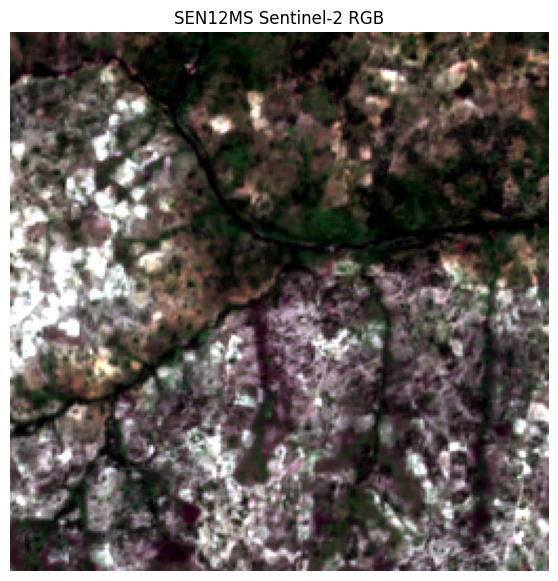

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.imshow(s2_rgb)
plt.title("SEN12MS Sentinel-2 RGB")
plt.axis("off")
plt.show()

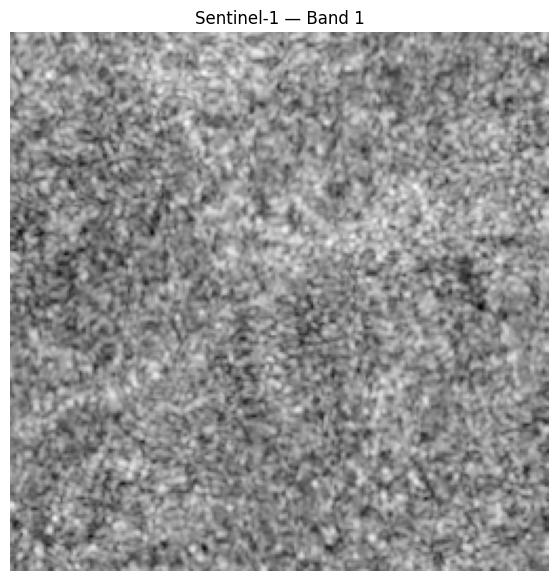

In [17]:
plt.figure(figsize=(7, 7))
plt.imshow(s1.data[0], cmap="gray")
plt.title("Sentinel-1 — Band 1")
plt.axis("off")
plt.show()

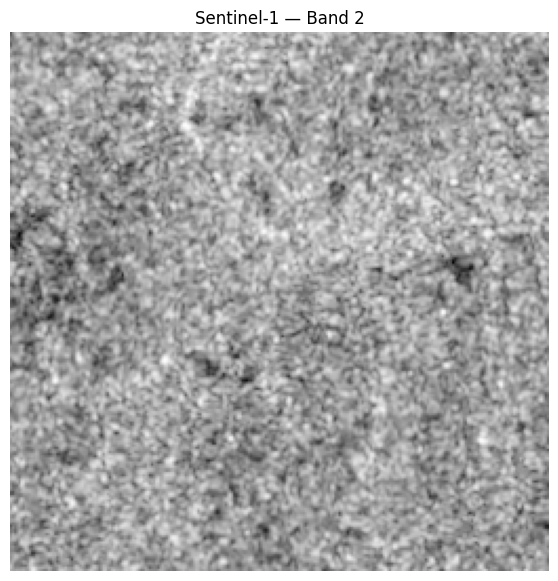

In [18]:
plt.figure(figsize=(7, 7))
plt.imshow(s1.data[1], cmap="gray")
plt.title("Sentinel-1 — Band 2")
plt.axis("off")
plt.show()

In [19]:
# ============================================================
# PART 3.1 — SATQUERY TASK DEFINITIONS
# ============================================================

TASKS = {
    "captioning": "Generate a description of the satellite image.",
    "vqa": "Answer a question about the satellite image.",
    "grounding": "Locate a requested object or region in the satellite image.",
    "cross_modal": "Analyze information jointly from Sentinel-1 and Sentinel-2."
}

print("SatQuery tasks:")
for task, description in TASKS.items():
    print(f"\n{task.upper()}")
    print(description)

SatQuery tasks:

CAPTIONING
Generate a description of the satellite image.

VQA
Answer a question about the satellite image.

GROUNDING
Locate a requested object or region in the satellite image.

CROSS_MODAL
Analyze information jointly from Sentinel-1 and Sentinel-2.


In [20]:
# ============================================================
# UPDATED TASK ROUTER
# ============================================================

def route_query(query):

    q = query.lower().strip()

    # --------------------------------------------------------
    # 1. Cross-modal
    # --------------------------------------------------------

    cross_modal_words = [
        "compare",
        "comparison",
        "difference between",
        "both images",
        "both",
        "sar and optical",
        "sentinel-1 and sentinel-2",
        "sentinel 1 and sentinel 2",
        "s1 and s2",
        "cross-modal"
    ]

    # --------------------------------------------------------
    # 2. Grounding
    # --------------------------------------------------------

    grounding_words = [
        "where is",
        "where are",
        "locate",
        "location of",
        "highlight",
        "find the",
        "find",
        "show me",
        "show where",
        "identify the location",
        "identify where",
        "point out",
        "detect",
        "bounding box",
        "bounding boxes",
        "ground"
    ]

    # --------------------------------------------------------
    # 3. Captioning
    # --------------------------------------------------------

    caption_words = [
        "describe",
        "caption",
        "what does the image show",
        "what is shown",
        "give me a description"
    ]

    # --------------------------------------------------------
    # 4. MCQ
    # --------------------------------------------------------

    mcq_patterns = [
        "options:",
        "choose the best answer",
        "multiple choice",
        "a.",
        "b.",
        "c.",
        "d."
    ]

    # --------------------------------------------------------
    # Priority
    # --------------------------------------------------------

    if any(word in q for word in cross_modal_words):
        return "cross_modal"

    if any(word in q for word in grounding_words):
        return "grounding"

    if any(word in q for word in caption_words):
        return "captioning"

    if any(pattern in q for pattern in mcq_patterns):
        return "mcq"

    return "vqa"

In [21]:
# ============================================================
# PART 3.3 — ROUTER TEST
# ============================================================

test_queries = [
    "Describe this satellite image.",
    "Is there water in this image?",
    "Where is the water?",
    "Locate the buildings.",
    "Compare the Sentinel-1 and Sentinel-2 images.",
    "What does the image show?",
    "Are there forests in the image?"
]

for query in test_queries:
    task = route_query(query)

    print(f"\nQuery : {query}")
    print(f"Route : {task}")


Query : Describe this satellite image.
Route : captioning

Query : Is there water in this image?
Route : vqa

Query : Where is the water?
Route : grounding

Query : Locate the buildings.
Route : grounding

Query : Compare the Sentinel-1 and Sentinel-2 images.
Route : cross_modal

Query : What does the image show?
Route : captioning

Query : Are there forests in the image?
Route : vqa


In [22]:
# ============================================================
# PART 3.4 — MODALITY DETECTION
# ============================================================

def detect_modality(query):
    """
    Determine which satellite modality is needed.
    """

    q = query.lower()

    s1_words = [
        "sar",
        "sentinel-1",
        "sentinel 1",
        "s1"
    ]

    s2_words = [
        "optical",
        "sentinel-2",
        "sentinel 2",
        "s2"
    ]

    has_s1 = any(word in q for word in s1_words)
    has_s2 = any(word in q for word in s2_words)

    if has_s1 and has_s2:
        return "S1+S2"

    if has_s1:
        return "S1"

    if has_s2:
        return "S2"

    return "AUTO"

In [23]:
test_queries = [
    "Describe the SAR image.",
    "Is there vegetation in the optical image?",
    "Compare Sentinel-1 and Sentinel-2.",
    "Is there water?"
]

for query in test_queries:
    print("\nQuery:", query)
    print("Task:", route_query(query))
    print("Modality:", detect_modality(query))


Query: Describe the SAR image.
Task: captioning
Modality: S1

Query: Is there vegetation in the optical image?
Task: vqa
Modality: S2

Query: Compare Sentinel-1 and Sentinel-2.
Task: cross_modal
Modality: S1+S2

Query: Is there water?
Task: vqa
Modality: AUTO


In [24]:
# ============================================================
# PART 3.5 — COMPLETE ROUTING DECISION
# ============================================================

def analyze_query(query):

    task = route_query(query)
    modality = detect_modality(query)

    return {
        "query": query,
        "task": task,
        "modality": modality
    }

In [25]:
queries = [
    "Describe this image.",
    "Is there water?",
    "Where is the water?",
    "Compare the SAR and optical imagery."
]

for query in queries:

    result = analyze_query(query)

    print("\n" + "=" * 50)
    print("QUERY:", result["query"])
    print("TASK:", result["task"])
    print("MODALITY:", result["modality"])


QUERY: Describe this image.
TASK: captioning
MODALITY: AUTO

QUERY: Is there water?
TASK: vqa
MODALITY: AUTO

QUERY: Where is the water?
TASK: grounding
MODALITY: AUTO

QUERY: Compare the SAR and optical imagery.
TASK: cross_modal
MODALITY: S1+S2


In [26]:
!pip -q install -U transformers accelerate pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.2 MB/s eta 0:00:00


In [27]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.17.0
CUDA available: True
GPU: Tesla T4


In [28]:
import os
import rasterio
import numpy as np
from PIL import Image

S2_DIR = "/content/sen12ms/s2"

s2_files = sorted([
    os.path.join(S2_DIR, f)
    for f in os.listdir(S2_DIR)
    if f.endswith(".tif")
])

print("S2 files:")
for f in s2_files:
    print(f)

s2_path = s2_files[0]

with rasterio.open(s2_path) as src:
    s2 = src.read()

print("\nS2:")
print("Shape:", s2.shape)
print("Dtype:", s2.dtype)
print("Min:", s2.min())
print("Max:", s2.max())

S2 files:
/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif
/content/sen12ms/s2/ROIs1158_spring_s2_1_p101.tif
/content/sen12ms/s2/ROIs1158_spring_s2_1_p102.tif

S2:
Shape: (13, 256, 256)
Dtype: uint16
Min: 7
Max: 4955


RGB image shape: (256, 256, 3)
RGB dtype: uint8


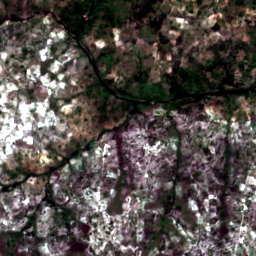

In [29]:
def normalize_band(band):
    band = band.astype(np.float32)

    p2 = np.percentile(band, 2)
    p98 = np.percentile(band, 98)

    band = (band - p2) / (p98 - p2 + 1e-8)
    band = np.clip(band, 0, 1)

    return band


# Use three S2 channels for the initial VLM experiment
blue = normalize_band(s2[1])
green = normalize_band(s2[2])
red = normalize_band(s2[3])

rgb = np.stack([red, green, blue], axis=-1)

rgb_uint8 = (rgb * 255).astype(np.uint8)

image = Image.fromarray(rgb_uint8)

print("RGB image shape:", rgb_uint8.shape)
print("RGB dtype:", rgb_uint8.dtype)

display(image)

In [30]:
import PIL
from PIL import Image

print("Pillow:", PIL.__version__)
print("PIL path:", PIL.__file__)
print("✓ PIL Image imported")

Pillow: 11.3.0
PIL path: /usr/local/lib/python3.13/dist-packages/PIL/__init__.py
✓ PIL Image imported


In [31]:
import PIL
from PIL import Image
import PIL._typing as typing

print("Pillow:", PIL.__version__)
print("PIL:", PIL.__file__)
print("_Ink exists:", hasattr(typing, "_Ink"))

Pillow: 11.3.0
PIL: /usr/local/lib/python3.13/dist-packages/PIL/__init__.py
_Ink exists: False


In [32]:
import cv2
import numpy as np

In [33]:
import torch
import cv2
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.17.0
OpenCV: 5.0.0
CUDA available: True


In [34]:
import os
import sys

print("Python:", sys.version)

try:
    import PIL
    print("PIL version:", PIL.__version__)
    print("PIL location:", PIL.__file__)
    print("PIL directory exists:", os.path.exists(PIL.__path__[0]))
except Exception as e:
    print("PIL error:", repr(e))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PIL version: 11.3.0
PIL location: /usr/local/lib/python3.13/dist-packages/PIL/__init__.py
PIL directory exists: True


In [35]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--no-cache-dir",
    "--force-reinstall",
    "Pillow==11.3.0"
])

print("✓ Pillow installed")
print("⚠️ Restart the runtime now")

✓ Pillow installed
⚠️ Restart the runtime now


In [36]:
from PIL import ImageDraw
import PIL

print("Pillow:", PIL.__version__)
print("✓ ImageDraw imported")

Pillow: 11.3.0
✓ ImageDraw imported


In [37]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("✓ Torchvision imported")

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
✓ Torchvision imported


In [38]:
from transformers import AutoProcessor

print("✓ AutoProcessor imported")

✓ AutoProcessor imported


In [39]:
from transformers import AutoModelForImageTextToText

print("✓ AutoModelForImageTextToText imported")

✓ AutoModelForImageTextToText imported


In [40]:
# ============================================================
# PART 4.4 — LOAD IMAGE-TEXT-TO-TEXT VLM (FAST)
# ============================================================

import torch

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# Prefer CUDA → MPS → CPU; use half precision wherever possible
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.float16
else:
    device = "cpu"
    dtype = torch.float32

processor = AutoProcessor.from_pretrained(MODEL_ID)

# Biggest speed win: disable image splitting + shrink longest edge
# Default SmolVLM splitting multiplies vision tokens and latency heavily
try:
    processor.image_processor.do_image_splitting = False
except Exception:
    pass

try:
    # Keep enough detail for satellite VQA, but cut vision cost a lot
    processor.image_processor.size = {"longest_edge": 512}
except Exception:
    pass

model_kwargs = {
    "torch_dtype": dtype,
    "trust_remote_code": True,
}
# Fast attention on CUDA / modern PyTorch
if device == "cuda":
    model_kwargs["attn_implementation"] = "sdpa"

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    **model_kwargs
)
model = model.to(device)
model.eval()

# Shared fast generate defaults used by all SatQuery helpers
FAST_GEN_KWARGS = dict(
    do_sample=False,
    use_cache=True,
    num_beams=1,
)

print("=" * 60)
print("VLM LOADED (FAST MODE)")
print("=" * 60)
print("Model :", MODEL_ID)
print("Device:", device)
print("Dtype :", dtype)
print("Image splitting:", getattr(processor.image_processor, "do_image_splitting", "n/a"))
print("Longest edge   :", getattr(processor.image_processor, "size", "n/a"))

if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

VLM LOADED (FAST MODE)
Model : HuggingFaceTB/SmolVLM-500M-Instruct
Device: cuda
Dtype : torch.bfloat16
Image splitting: False
Longest edge   : {'longest_edge': 512}
GPU   : Tesla T4


In [115]:
# ============================================================
# STEP 8 — SINGLE IMAGE VLM TEST
# ============================================================

# Use one RGB image already available in the notebook.
# Replace `rgb_image` with the variable containing your image
# if your current notebook uses a different variable name.

test_image = image

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": "Describe what you see in this image in one short sentence."
            }
        ],
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[test_image],
    return_tensors="pt"
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
    if torch.is_tensor(v)
}

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False,
        use_cache=True,
        num_beams=1
    )

output = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("=" * 60)
print("SINGLE IMAGE TEST")
print("=" * 60)
print(output)


SINGLE IMAGE TEST
User:Describe what you see in this image in one short sentence.
Assistant: A close-up of a textured, rough surface with a few small, dark spots.


In [42]:
# ============================================================
# PART 4.5.1 — LOAD SEN12MS PATCH
# ============================================================

import os
import rasterio
import numpy as np

S2_DIR = "/content/sen12ms/s2"

s2_path = os.path.join(
    S2_DIR,
    "ROIs1158_spring_s2_1_p100.tif"
)

with rasterio.open(s2_path) as src:
    s2 = src.read()

print("=" * 60)
print("S2 PATCH LOADED")
print("=" * 60)

print("Path :", s2_path)
print("Shape:", s2.shape)
print("Dtype:", s2.dtype)
print("Min  :", s2.min())
print("Max  :", s2.max())

S2 PATCH LOADED
Path : /content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif
Shape: (13, 256, 256)
Dtype: uint16
Min  : 7
Max  : 4955


RGB shape: (256, 256, 3)
RGB dtype: uint8


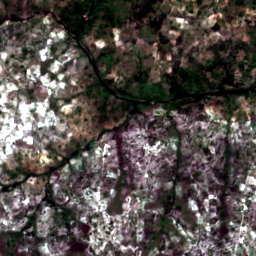

In [43]:
def normalize_band(band):
    band = band.astype(np.float32)

    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    band = (band - low) / (high - low + 1e-8)
    band = np.clip(band, 0, 1)

    return band


# Initial RGB representation
blue  = normalize_band(s2[1])
green = normalize_band(s2[2])
red   = normalize_band(s2[3])

rgb = np.stack(
    [red, green, blue],
    axis=-1
)

rgb_uint8 = (rgb * 255).astype(np.uint8)

image = Image.fromarray(rgb_uint8)

print("RGB shape:", rgb_uint8.shape)
print("RGB dtype:", rgb_uint8.dtype)

display(image)

In [44]:
# ============================================================
# PART 4.5.3 — FIRST VLM INFERENCE
# ============================================================

question = "is there water?."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image"
            },
            {
                "type": "text",
                "text": question
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    if hasattr(value, "to")
    else value
    for key, value in inputs.items()
}

print("Inputs prepared.")

Inputs prepared.


In [116]:
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
        use_cache=True,
        num_beams=1
    )

answer = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("=" * 60)
print("VLM RESPONSE")
print("=" * 60)
print(answer)


VLM RESPONSE
User:Describe what you see in this image in one short sentence.
Assistant: A close-up of a textured, rough surface with a few small, dark spots.


In [46]:
# ============================================================
# PART 5.1 — UNIVERSAL SATELLITE IMAGE LOADER
# Supports:
#   JPG / JPEG / PNG
#   GeoTIFF / TIFF
# ============================================================

import os
import cv2
import rasterio
import numpy as np


def load_satellite_image(path):

    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

    extension = os.path.splitext(path)[1].lower()

    # --------------------------------------------------------
    # NORMAL IMAGE
    # --------------------------------------------------------
    if extension in [".jpg", ".jpeg", ".png"]:

        image = cv2.imread(path)

        if image is None:
            raise ValueError(f"Could not read image: {path}")

        # BGR → RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        return {
            "input_type": "image",
            "path": path,
            "image": image,
            "array": image,
            "bands": 3,
            "width": image.shape[1],
            "height": image.shape[0],
            "crs": None
        }

    # --------------------------------------------------------
    # TIFF / GEOTIFF
    # --------------------------------------------------------
    elif extension in [".tif", ".tiff"]:

        with rasterio.open(path) as src:

            data = src.read()

            metadata = {
                "crs": src.crs,
                "bounds": src.bounds,
                "transform": src.transform,
                "width": src.width,
                "height": src.height,
                "dtype": src.dtypes
            }

        return {
            "input_type": "tiff",
            "path": path,
            "array": data,
            "bands": data.shape[0],
            "width": data.shape[2],
            "height": data.shape[1],
            "crs": metadata["crs"],
            "bounds": metadata["bounds"],
            "transform": metadata["transform"],
            "dtype": metadata["dtype"]
        }

    else:
        raise ValueError(
            f"Unsupported file type: {extension}. "
            "Use JPG, JPEG, PNG, TIFF, or GeoTIFF."
        )

In [47]:
# ============================================================
# PART 5.2 — CONVERT INPUT TO VLM-READY RGB (FAST)
# ============================================================

MAX_VLM_SIDE = 512  # downsample before vision encoder


def normalize_band(band):
    band = band.astype(np.float32)

    # Faster approx percentiles via strided subsample on large bands
    flat = band.ravel()
    if flat.size > 200_000:
        flat = flat[:: max(1, flat.size // 100_000)]

    low = np.percentile(flat, 2)
    high = np.percentile(flat, 98)
    band = (band - low) / (high - low + 1e-8)
    return np.clip(band, 0, 1)


def _resize_rgb(rgb_uint8, max_side=MAX_VLM_SIDE):
    h, w = rgb_uint8.shape[:2]
    scale = max_side / max(h, w)
    if scale >= 1.0:
        return rgb_uint8
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    return cv2.resize(rgb_uint8, (new_w, new_h), interpolation=cv2.INTER_AREA)


def prepare_vlm_image(data):
    # --------------------------------------------------------
    # Normal RGB image
    # --------------------------------------------------------
    if data["input_type"] == "image":
        image = data["image"]
        if image.dtype != np.uint8:
            image = np.clip(image, 0, 255).astype(np.uint8)
        return _resize_rgb(image)

    # --------------------------------------------------------
    # TIFF
    # --------------------------------------------------------
    array = data["array"]
    bands = array.shape[0]

    if bands >= 4:
        # Sentinel-2 RGB
        blue = normalize_band(array[1])
        green = normalize_band(array[2])
        red = normalize_band(array[3])
        rgb = np.stack([red, green, blue], axis=-1)
    elif bands == 3:
        rgb = np.transpose(array, (1, 2, 0)).astype(np.float32)
        # normalize each channel lightly
        for c in range(3):
            rgb[..., c] = normalize_band(rgb[..., c])
    elif bands == 2:
        # Sentinel-1 representation
        first = normalize_band(array[0])
        second = normalize_band(array[1])
        third = np.zeros_like(first)
        rgb = np.stack([first, second, third], axis=-1)
    else:
        raise ValueError(
            f"Cannot create RGB representation from {bands} bands."
        )

    rgb_uint8 = (rgb * 255).astype(np.uint8)
    return _resize_rgb(rgb_uint8)


Type : image
Size : 256 x 256
Bands: 3


array([[[ 63,  48,  46],
        [ 45,  41,  35],
        [ 22,  29,  17],
        ...,
        [ 26,  27,  23],
        [  9,   9,   7],
        [ 20,  27,  16]],

       [[ 74,  58,  56],
        [ 56,  50,  44],
        [ 28,  32,  25],
        ...,
        [ 26,  25,  22],
        [  8,   2,   4],
        [ 14,  18,  13]],

       [[ 83,  65,  62],
        [ 72,  62,  56],
        [ 48,  52,  43],
        ...,
        [ 14,   7,   7],
        [  6,   0,   0],
        [ 14,  13,   8]],

       ...,

       [[ 75,  60,  62],
        [ 54,  32,  43],
        [ 44,  30,  32],
        ...,
        [111, 115, 110],
        [117, 117, 115],
        [103,  94,  99]],

       [[ 70,  58,  61],
        [ 57,  47,  47],
        [ 46,  39,  33],
        ...,
        [112, 121, 107],
        [130, 132, 127],
        [119, 111, 113]],

       [[ 98,  88,  86],
        [ 81,  68,  64],
        [ 54,  45,  40],
        ...,
        [120, 113, 112],
        [140, 130, 131],
        [130, 121, 119]]], dtype=uint8)
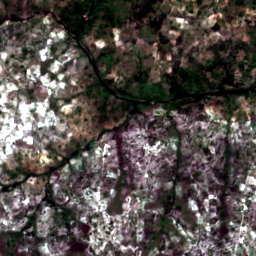

In [49]:
IMAGE_PATH = "/content/download.png"

data = load_satellite_image(IMAGE_PATH)

print("Type :", data["input_type"])
print("Size :", data["width"], "x", data["height"])
print("Bands:", data["bands"])

vlm_image = prepare_vlm_image(data)

display(vlm_image)

In [50]:
# ============================================================
# PART 5.5 — SATQUERY ROUTING PIPELINE
# ============================================================

def satquery_route(input_path, query):

    # Load image
    data = load_satellite_image(input_path)

    # Analyze user intent
    routing = analyze_query(query)

    # Prepare visual representation
    vlm_image = prepare_vlm_image(data)

    return {
        "input": data,
        "vlm_image": vlm_image,
        "query": query,
        "task": routing["task"],
        "modality": routing["modality"]
    }

In [51]:
result = satquery_route(
    "/content/sen12ms//s2/ROIs1158_spring_s2_1_p100.tif",
    "Is there water?"
)

print("=" * 60)
print("SATQUERY ROUTING")
print("=" * 60)

print("Query   :", result["query"])
print("Task    :", result["task"])
print("Modality:", result["modality"])
print("Input   :", result["input"]["input_type"])
print("Bands   :", result["input"]["bands"])

SATQUERY ROUTING
Query   : Is there water?
Task    : vqa
Modality: AUTO
Input   : tiff
Bands   : 13


In [52]:
# ============================================================
# PART 5.3 — PREPARE REAL SEN12MS IMAGE
# ============================================================

S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

data = load_satellite_image(S2_PATH)

vlm_image = prepare_vlm_image(data)

print("=" * 60)
print("SEN12MS IMAGE READY")
print("=" * 60)

print("Input type :", data["input_type"])
print("Bands      :", data["bands"])
print("Size       :", data["width"], "x", data["height"])
print("CRS        :", data["crs"])
print("VLM shape  :", vlm_image.shape)
print("VLM dtype  :", vlm_image.dtype)

SEN12MS IMAGE READY
Input type : tiff
Bands      : 13
Size       : 256 x 256
CRS        : EPSG:32737
VLM shape  : (256, 256, 3)
VLM dtype  : uint8


In [53]:
# ============================================================
# PART 6F — PREPARE MULTIMODAL INPUT
# ============================================================

S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

data = load_satellite_image(S2_PATH)
vlm_image = prepare_vlm_image(data)

question = "Is there water in this satellite image?"

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {
                "type": "text",
                "text": question,
            },
        ],
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

print("Prompt:")
print(prompt)

Prompt:
<|im_start|>User:<image>Is there water in this satellite image?<end_of_utterance>
Assistant:


In [54]:
# ============================================================
# PART 6G — PROCESS IMAGE + TEXT
# ============================================================

inputs = processor(
    text=prompt,
    images=[vlm_image],
    return_tensors="pt"
)

print("Inputs created:")
for key, value in inputs.items():
    if hasattr(value, "shape"):
        print(key, ":", value.shape)
    else:
        print(key, ":", type(value))

Inputs created:
input_ids : torch.Size([1, 83])
attention_mask : torch.Size([1, 83])
pixel_values : torch.Size([1, 1, 3, 512, 512])
pixel_attention_mask : torch.Size([1, 1, 512, 512])


In [55]:
inputs = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}

print("Inputs moved to:", device)

Inputs moved to: cuda


In [117]:
# ============================================================
# PART 6H — SATQUERY VQA GENERATION
# ============================================================

print("Generating answer...")
print("Device:", device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

answer = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("=" * 60)
print("SATQUERY VQA RESULT")
print("=" * 60)
print("Question:", question)
print("Answer  :", answer)

Generating answer...
Device: cuda
SATQUERY VQA RESULT
Question: What can you observe in this satellite image? in 2 complete sentences
Answer  : User:Describe what you see in this image in one short sentence.
Assistant: A close-up of a textured, rough surface with a few small, dark spots.


In [57]:
# ============================================================
# PART 6I — CLEAN VLM ANSWER
# ============================================================

clean_answer = answer

if "Assistant:" in clean_answer:
    clean_answer = clean_answer.split("Assistant:", 1)[1].strip()

print("=" * 60)
print("FINAL SATQUERY ANSWER")
print("=" * 60)
print(clean_answer)

FINAL SATQUERY ANSWER
No, there is no water visible in this satellite


In [60]:
question = "What can you observe in this satellite image?"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt"
)

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

print(inputs.keys())


dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'pixel_attention_mask'])


In [61]:
# ============================================================
# PART 6G — PROCESS IMAGE + TEXT
# ============================================================

question = "What can you observe in this satellite image? in 2 complete sentences"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt"
)

inputs = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}

print("Inputs ready:", list(inputs.keys()))
print("Device:", device)

Inputs ready: ['input_ids', 'attention_mask', 'pixel_values', 'pixel_attention_mask']
Device: cuda


In [62]:
# ============================================================
# PART 6H — VLM GENERATION
# ============================================================

print("Generating answer...")

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False
    )

answer = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("=" * 60)
print("SATQUERY VLM RESULT")
print("=" * 60)
print("Question:", question)
print("Answer:", answer)

Generating answer...
SATQUERY VLM RESULT
Question: What can you observe in this satellite image? in 2 complete sentences
Answer: User:What can you observe in this satellite image? in 2 complete sentences
Assistant: The satellite image shows a large, dark, rocky, and uneven surface. The surface is covered with a variety of rocks and boulders, with some areas appearing more rugged and uneven than others. The surface is littered with small, dark patches, which may be caused by the presence of vegetation or other geological features. The overall appearance of the surface suggests a rugged and possibly barren landscape, with no signs


In [63]:
# ============================================================
# PART 6I — CLEAN VLM RESPONSE
# ============================================================

clean_answer = answer

if "Assistant:" in clean_answer:
    clean_answer = clean_answer.split("Assistant:", 1)[1].strip()

print("=" * 60)
print("CLEAN SATQUERY ANSWER")
print("=" * 60)
print(clean_answer)

CLEAN SATQUERY ANSWER
The satellite image shows a large, dark, rocky, and uneven surface. The surface is covered with a variety of rocks and boulders, with some areas appearing more rugged and uneven than others. The surface is littered with small, dark patches, which may be caused by the presence of vegetation or other geological features. The overall appearance of the surface suggests a rugged and possibly barren landscape, with no signs


In [64]:
def satquery_vqa(input_path, question, max_new_tokens=80):

    # Step 1: Load image
    data = load_satellite_image(input_path)

    # Step 2: Convert to VLM-ready RGB
    image = prepare_vlm_image(data)

    # Step 3: Build multimodal prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    # Step 4: Process image + text
    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    )

    # Step 5: Move tensors to device
    inputs = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    # Step 6: Generate (fast)
    gen_kwargs = dict(FAST_GEN_KWARGS) if "FAST_GEN_KWARGS" in globals() else dict(do_sample=False, use_cache=True)
    gen_kwargs["max_new_tokens"] = max_new_tokens
    pad_id = getattr(processor.tokenizer, "pad_token_id", None)
    if pad_id is not None:
        gen_kwargs["pad_token_id"] = pad_id

    with torch.inference_mode():
        generated_ids = model.generate(**inputs, **gen_kwargs)

    # Step 7: Remove prompt tokens
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = generated_ids[:, input_length:]

    # Step 8: Decode
    answer = processor.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0].strip()

    return answer


In [65]:
satquery_vqa(
    "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif",
    "Is there water?"
)

'Yes, there is water visible in the image.'

In [118]:
# ============================================================
# PART 8 — UNIVERSAL MCQ VQA (FAST)
# ============================================================

def satquery_mcq(
    input_path,
    question,
    options,
    max_new_tokens=100
):
    """
    MCQ VQA for satellite images.

    Supports:
        JPG / JPEG / PNG
        TIFF / GeoTIFF

    options example:
    {
        "A": "Dense forest",
        "B": "Urban area",
        "C": "Open water",
        "D": "Snow"
    }
    """

    # --------------------------------------------------
    # 1. Load image
    # --------------------------------------------------
    data = load_satellite_image(input_path)

    # --------------------------------------------------
    # 2. Convert to VLM-ready RGB
    # --------------------------------------------------
    image = prepare_vlm_image(data)

    # --------------------------------------------------
    # 3. Format options
    # --------------------------------------------------
    option_text = "\n".join(
        f"{key}. {value}"
        for key, value in options.items()
    )

    # --------------------------------------------------
    # 4. Construct question (ask for letter only → fewer tokens)
    # --------------------------------------------------
    full_question = f"""{question}

Options:
{option_text}

Reply with only the option letter (A/B/C/D)."""

    # --------------------------------------------------
    # 5. Build multimodal prompt
    # --------------------------------------------------
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": full_question
                }
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    # --------------------------------------------------
    # 6. Process image + text
    # --------------------------------------------------
    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    )

    # --------------------------------------------------
    # 7. Move tensors to CPU/GPU
    # --------------------------------------------------
    inputs = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    # --------------------------------------------------
    # 8. Generate (fast)
    # --------------------------------------------------
    gen_kwargs = dict(FAST_GEN_KWARGS) if "FAST_GEN_KWARGS" in globals() else dict(do_sample=False, use_cache=True)
    gen_kwargs["max_new_tokens"] = max_new_tokens
    pad_id = getattr(processor.tokenizer, "pad_token_id", None)
    if pad_id is not None:
        gen_kwargs["pad_token_id"] = pad_id

    with torch.inference_mode():
        generated_ids = model.generate(**inputs, **gen_kwargs)

    # --------------------------------------------------
    # 9. Remove prompt tokens
    # --------------------------------------------------
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = generated_ids[:, input_length:]

    # --------------------------------------------------
    # 10. Decode
    # --------------------------------------------------
    answer = processor.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0].strip()

    return answer


In [67]:
S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

options = {
    "A": "Dense forest",
    "B": "Urban area",
    "C": "Open water",
    "D": "Rocky or barren land"
}

mcq_answer = satquery_mcq(
    S2_PATH,
    "What is the dominant land cover in this satellite image?",
    options,
    max_new_tokens=30
)

print("=" * 60)
print("SATQUERY MCQ RESULT")
print("=" * 60)
print(mcq_answer)

SATQUERY MCQ RESULT
Answer: C


In [68]:
# ============================================================
# PART 9.1 — TEXT-GUIDED GROUNDING TEST
# ============================================================

grounding_question = """
Locate the main vegetation visible in this satellite image.

Return your answer in exactly this format:

Object: vegetation
Location: describe where it appears in the image
"""

grounding_answer = satquery_vqa(
    S2_PATH,
    grounding_question,
    max_new_tokens=50
)

print("=" * 60)
print("SATQUERY GROUNDING TEST")
print("=" * 60)
print(grounding_answer)

SATQUERY GROUNDING TEST
Trees.


In [69]:
# ============================================================
# PART 9.2 — REQUEST NORMALIZED BOUNDING BOX
# ============================================================

grounding_question = """
Find the main trees or vegetation in this image.

Return ONLY one bounding box in this exact format:

[x1, y1, x2, y2]

Use normalized coordinates between 0 and 1:
x1 = left
y1 = top
x2 = right
y2 = bottom

Do not provide any explanation.
"""

grounding_answer = satquery_vqa(
    S2_PATH,
    grounding_question,
    max_new_tokens=30
)

print("=" * 60)
print("SATQUERY GROUNDING COORDINATES")
print("=" * 60)
print(grounding_answer)

SATQUERY GROUNDING COORDINATES
[0.0, 0.0, 1.0, 1.0].


In [70]:
# ============================================================
# PART 9.3 — CHECK SMOLVLM GROUNDING CAPABILITY
# ============================================================

print("Model class:", type(model).__name__)
print("Model config:", model.config.model_type)

# Check whether the model exposes any obvious grounding-related
# generation/output functionality.

grounding_keywords = [
    "box",
    "bbox",
    "bounding",
    "ground",
    "coordinate"
]

model_attributes = dir(model)

matches = [
    attr for attr in model_attributes
    if any(word in attr.lower() for word in grounding_keywords)
]

print("\nPotential grounding-related attributes:")
print(matches)

Model class: Idefics3ForConditionalGeneration
Model config: idefics3

Potential grounding-related attributes:
[]


In [71]:
# ============================================================
# PART 9.4 — CHECK GROUNDING IMAGE
# ============================================================

print("Image type:", type(vlm_image))
print("Image size:", vlm_image.size)

print("=" * 60)
print("GROUNDING IMAGE READY")
print("=" * 60)

Image type: <class 'numpy.ndarray'>
Image size: 196608
GROUNDING IMAGE READY


In [72]:
# ============================================================
# PART 9.4 — CREATE DEFINITIVE VLM RGB IMAGE
# ============================================================

import numpy as np
from PIL import Image

S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

# Load Sentinel-2
data = load_satellite_image(S2_PATH)

# Get multispectral array
array = data["array"]

# Sentinel-2 RGB bands
blue = array[1].astype(np.float32)   # B2
green = array[2].astype(np.float32)  # B3
red = array[3].astype(np.float32)    # B4

def normalize_for_rgb(band):
    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    band = np.clip(band, low, high)

    if high > low:
        band = (band - low) / (high - low)
    else:
        band = np.zeros_like(band)

    return band

red = normalize_for_rgb(red)
green = normalize_for_rgb(green)
blue = normalize_for_rgb(blue)

rgb = np.stack([red, green, blue], axis=-1)

rgb_uint8 = (rgb * 255).astype(np.uint8)

# DEFINITIVELY convert to PIL
vlm_image = Image.fromarray(rgb_uint8)

print("Image type:", type(vlm_image))
print("Image size:", vlm_image.size)
print("Image mode:", vlm_image.mode)

Image type: <class 'PIL.Image.Image'>
Image size: (256, 256)
Image mode: RGB


In [73]:
# ============================================================
# PART 9.5 — INSTALL GROUNDING DEPENDENCIES
# ============================================================

!pip -q install transformers timm

print("Grounding dependencies installed.")

Grounding dependencies installed.


In [74]:
# ============================================================
# PART 9.6 — LOAD GROUNDING MODEL
# ============================================================

import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

GROUNDING_MODEL_ID = "IDEA-Research/grounding-dino-base"

grounding_processor = AutoProcessor.from_pretrained(
    GROUNDING_MODEL_ID
)

grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GROUNDING_MODEL_ID
)

grounding_device = "cuda" if torch.cuda.is_available() else "cpu"

grounding_model = grounding_model.to(grounding_device)
grounding_model.eval()

print("=" * 60)
print("GROUNDING MODEL LOADED")
print("=" * 60)
print("Model :", GROUNDING_MODEL_ID)
print("Device:", grounding_device)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  933MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

GROUNDING MODEL LOADED
Model : IDEA-Research/grounding-dino-base
Device: cuda


In [75]:
# ============================================================
# PART 9.7 — FIRST GROUNDING INFERENCE
# ============================================================

text_prompt = "trees."

# Prepare image + text
grounding_inputs = grounding_processor(
    images=vlm_image,
    text=text_prompt,
    return_tensors="pt"
)

# Move tensors to CPU/GPU
grounding_inputs = {
    k: v.to(grounding_device) if torch.is_tensor(v) else v
    for k, v in grounding_inputs.items()
}

print("Running grounding inference...")

with torch.no_grad():
    grounding_outputs = grounding_model(**grounding_inputs)

print("Grounding inference complete.")

Running grounding inference...
Grounding inference complete.


In [76]:
# ============================================================
# PART 9.8 — EXTRACT BOUNDING BOXES
# ============================================================

results = grounding_processor.post_process_grounded_object_detection(
    grounding_outputs,
    threshold=0.25,
    text_threshold=0.20,
    target_sizes=[vlm_image.size[::-1]]
)

result = results[0]

print("=" * 60)
print("GROUNDING RESULTS")
print("=" * 60)

print("Number of detections:", len(result["boxes"]))

for i, (box, score, label) in enumerate(
    zip(result["boxes"], result["scores"], result["text_labels"])
):
    print(f"\nDetection {i + 1}")
    print("Label :", label)
    print("Score :", round(float(score), 3))
    print("Box   :", [round(float(x), 1) for x in box])

GROUNDING RESULTS
Number of detections: 1

Detection 1
Label : trees
Score : 0.626
Box   : [0.0, -0.2, 256.0, 255.8]


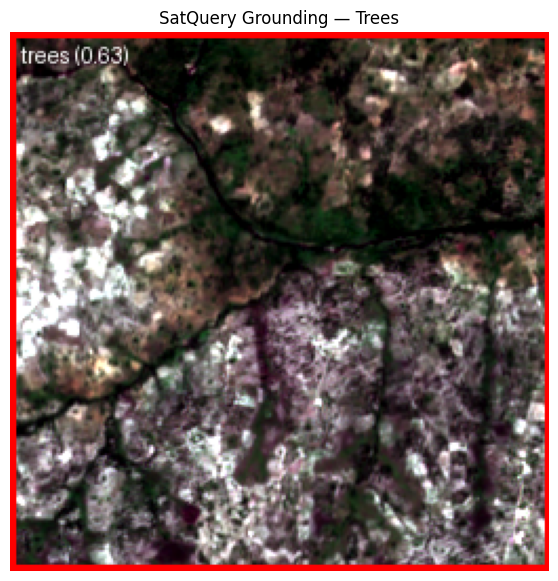

In [77]:
# ============================================================
# PART 9.9 — VISUALIZE GROUNDING BOX
# ============================================================

import matplotlib.pyplot as plt
from PIL import ImageDraw

# Make a copy so the original stays unchanged
grounding_image = vlm_image.copy()

draw = ImageDraw.Draw(grounding_image)

for box, score, label in zip(
    result["boxes"],
    result["scores"],
    result["text_labels"]
):
    x1, y1, x2, y2 = [float(x) for x in box]

    # Keep coordinates inside image
    x1 = max(0, min(x1, grounding_image.width))
    y1 = max(0, min(y1, grounding_image.height))
    x2 = max(0, min(x2, grounding_image.width))
    y2 = max(0, min(y2, grounding_image.height))

    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=3
    )

    draw.text(
        (x1 + 5, max(0, y1 + 5)),
        f"{label} ({float(score):.2f})"
    )

plt.figure(figsize=(7, 7))
plt.imshow(grounding_image)
plt.axis("off")
plt.title("SatQuery Grounding — Trees")
plt.show()

In [78]:
# ============================================================
# PART 9.10 — TEST MULTIPLE GROUNDING PROMPTS
# ============================================================

test_prompts = [
    "road",
    "water",
    "building",
    "forest"
]

for text_prompt in test_prompts:

    grounding_inputs = grounding_processor(
        images=vlm_image,
        text=text_prompt,
        return_tensors="pt"
    )

    grounding_inputs = {
        k: v.to(grounding_device) if torch.is_tensor(v) else v
        for k, v in grounding_inputs.items()
    }

    with torch.no_grad():
        outputs = grounding_model(**grounding_inputs)

    results_test = grounding_processor.post_process_grounded_object_detection(
        outputs,
        threshold=0.30,
        text_threshold=0.20,
        target_sizes=[vlm_image.size[::-1]]
    )

    r = results_test[0]

    print("\nPrompt:", text_prompt)
    print("Detections:", len(r["boxes"]))

    for box, score, label in zip(
        r["boxes"],
        r["scores"],
        r["text_labels"]
    ):
        print(
            " ",
            label,
            "score =", round(float(score), 3),
            "box =", [round(float(x), 1) for x in box]
        )


Prompt: road
Detections: 0

Prompt: water
Detections: 0

Prompt: building
Detections: 0

Prompt: forest
Detections: 1
  forest score = 0.394 box = [0.0, -0.5, 256.0, 255.5]


In [79]:
# ============================================================
# PART 9.11 — REUSABLE SATQUERY GROUNDING
# ============================================================

def satquery_ground(
    input_path,
    text_prompt,
    threshold=0.25,
    text_threshold=0.20
):

    # Load image
    data = load_satellite_image(input_path)

    # Convert to RGB
    image = prepare_vlm_image(data)

    # Make sure image is a PIL RGB image
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))

    image = image.convert("RGB")

    # Prepare grounding inputs
    inputs = grounding_processor(
        images=image,
        text=text_prompt,
        return_tensors="pt"
    )

    # Move tensors to CPU/GPU
    inputs = {
        k: v.to(grounding_device)
        if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    # Grounding inference
    with torch.no_grad():
        outputs = grounding_model(**inputs)

    # Convert raw outputs to bounding boxes
    results = grounding_processor.post_process_grounded_object_detection(
        outputs,
        threshold=threshold,
        text_threshold=text_threshold,
        target_sizes=[(image.height, image.width)]
    )

    result = results[0]

    return {
        "image": image,
        "boxes": result["boxes"],
        "scores": result["scores"],
        "labels": result["text_labels"]
    }

In [80]:
result = satquery_ground(
    S2_PATH,
    "forest"
)

print("=" * 60)
print("SATQUERY GROUNDING")
print("=" * 60)

for box, score, label in zip(
    result["boxes"],
    result["scores"],
    result["labels"]
):
    print("Label :", label)
    print("Score :", round(float(score), 3))
    print("Box   :", [round(float(x), 1) for x in box])

SATQUERY GROUNDING
Label : forest
Score : 0.394
Box   : [0.0, -0.5, 256.0, 255.5]


In [81]:
# ============================================================
# PART 9.12 — VISUALIZE SATQUERY GROUNDING
# ============================================================

import matplotlib.pyplot as plt
from PIL import ImageDraw

def visualize_grounding(result):

    image = result["image"].copy()
    draw = ImageDraw.Draw(image)

    for box, score, label in zip(
        result["boxes"],
        result["scores"],
        result["labels"]
    ):

        x1, y1, x2, y2 = [float(x) for x in box]

        # Keep coordinates inside image
        x1 = max(0, min(x1, image.width))
        y1 = max(0, min(y1, image.height))
        x2 = max(0, min(x2, image.width))
        y2 = max(0, min(y2, image.height))

        # Draw bounding box
        draw.rectangle(
            [x1, y1, x2, y2],
            outline="red",
            width=3
        )

        # Label
        label_text = f"{label} ({float(score):.2f})"

        draw.text(
            (x1 + 5, y1 + 5),
            label_text
        )

    # Display
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.title("SatQuery Grounding")
    plt.show()

    return image

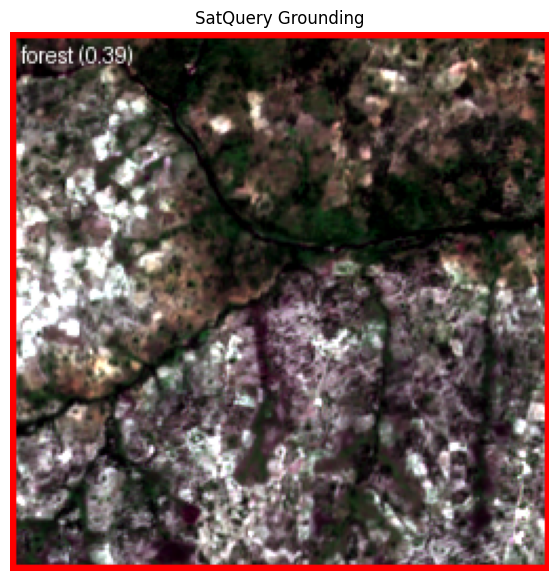

In [82]:
grounded_image = visualize_grounding(result)

In [119]:
# ============================================================
# PART 8.5 — SATQUERY CAPTIONING (FAST)
# ============================================================

def satquery_caption(
    input_path,
    max_new_tokens=200
):
    """
    Generate a natural-language caption
    for a satellite image.

    Supports:
        JPG / JPEG / PNG
        TIFF / GeoTIFF
    """

    # --------------------------------------------------------
    # 1. Load image
    # --------------------------------------------------------
    data = load_satellite_image(input_path)

    # --------------------------------------------------------
    # 2. Convert to RGB
    # --------------------------------------------------------
    image = prepare_vlm_image(data)

    # Make sure PIL RGB
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))

    image = image.convert("RGB")

    # --------------------------------------------------------
    # 3. Prompt (short → faster decode)
    # --------------------------------------------------------
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": (
                        "Describe this satellite image in 1-2 short sentences. "
                        "Mention main land cover: vegetation, water, urban, or bare land."
                    )
                }
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    # --------------------------------------------------------
    # 4. Process
    # --------------------------------------------------------
    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    )

    # --------------------------------------------------------
    # 5. Device
    # --------------------------------------------------------
    inputs = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    # --------------------------------------------------------
    # 6. Generate (fast)
    # --------------------------------------------------------
    gen_kwargs = dict(FAST_GEN_KWARGS) if "FAST_GEN_KWARGS" in globals() else dict(do_sample=False, use_cache=True)
    gen_kwargs["max_new_tokens"] = max_new_tokens
    pad_id = getattr(processor.tokenizer, "pad_token_id", None)
    if pad_id is not None:
        gen_kwargs["pad_token_id"] = pad_id

    with torch.inference_mode():
        generated_ids = model.generate(**inputs, **gen_kwargs)

    # --------------------------------------------------------
    # 7. Remove prompt
    # --------------------------------------------------------
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = generated_ids[:, input_length:]

    # --------------------------------------------------------
    # 8. Decode
    # --------------------------------------------------------
    caption = processor.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0].strip()

    return caption


In [84]:
# ============================================================
# PART 10.13 — MASTER SATQUERY WITH S1 + S2 SUPPORT
# ============================================================

def satquery(
    input_path,
    query,
    options=None,
    s1_path=None,
    s2_path=None,
    max_new_tokens=32
):
    """
    Main SatQuery interface.

    Supports:
        VQA
        MCQ
        Captioning
        Grounding
        S1 + S2 multimodal analysis
    """

    # --------------------------------------------------------
    # 1. Analyze query
    # --------------------------------------------------------

    routing = analyze_query(query)

    task = routing["task"]
    modality = routing["modality"]

    print("=" * 60)
    print("SATQUERY")
    print("=" * 60)
    print("Query   :", query)
    print("Task    :", task)
    print("Modality:", modality)

    # --------------------------------------------------------
    # 2. S1 + S2 multimodal
    # --------------------------------------------------------

    if s1_path is not None and s2_path is not None:

        result = satquery_multimodal(
            s1_path,
            s2_path,
            query,
            max_new_tokens=max_new_tokens
        )

        return {
            "task": "multimodal",
            "modality": "S1+S2",
            "answer": result["answer"],
            "s1_image": result["s1_image"],
            "s2_image": result["s2_image"]
        }

    # --------------------------------------------------------
    # 3. Captioning
    # --------------------------------------------------------

    if task == "captioning":

        answer = satquery_caption(
            input_path,
            max_new_tokens=max_new_tokens
        )

        return {
            "task": task,
            "modality": modality,
            "answer": answer
        }

    # --------------------------------------------------------
    # 4. MCQ
    # --------------------------------------------------------

    elif task == "mcq":

        if options is None:
            raise ValueError(
                "MCQ task requires options."
            )

        answer = satquery_mcq(
            input_path,
            query,
            options,
            max_new_tokens=max_new_tokens
        )

        return {
            "task": task,
            "modality": modality,
            "answer": answer
        }

    # --------------------------------------------------------
    # 5. Grounding
    # --------------------------------------------------------

    elif task == "grounding":

        result = satquery_ground(
            input_path,
            query
        )

        return {
            "task": task,
            "modality": modality,
            "image": result["image"],
            "boxes": result["boxes"],
            "scores": result["scores"],
            "labels": result["labels"]
        }

    # --------------------------------------------------------
    # 6. VQA
    # --------------------------------------------------------

    else:

        answer = satquery_vqa(
            input_path,
            query,
            max_new_tokens=max_new_tokens
        )

        return {
            "task": task,
            "modality": modality,
            "answer": answer
        }


In [85]:
# ============================================================
# PART 10.2 — END-TO-END SATQUERY VQA TEST
# ============================================================

test_result = satquery(
    S2_PATH,
    "Is there water in this satellite image?"
)

print("\n" + "=" * 60)
print("FINAL SATQUERY RESULT")
print("=" * 60)

print("Task   :", test_result["task"])
print("Answer :", test_result["answer"])

SATQUERY
Query   : Is there water in this satellite image?
Task    : vqa
Modality: AUTO

FINAL SATQUERY RESULT
Task   : vqa
Answer : No, there is no water visible in this satellite image.


In [86]:
# ============================================================
# PART 10.3 — INSPECT SENTINEL-1 PATCH
# ============================================================

S1_PATH = "/content/sen12ms/s1/ROIs1158_spring_s1_1_p100.tif"

with rasterio.open(S1_PATH) as src:
    s1 = src.read()

print("=" * 60)
print("S1 PATCH")
print("=" * 60)

print("Path :", S1_PATH)
print("Shape:", s1.shape)
print("Dtype:", s1.dtype)
print("Min  :", s1.min())
print("Max  :", s1.max())

for i in range(s1.shape[0]):
    print(
        f"Band {i + 1}: "
        f"min={s1[i].min():.4f}, "
        f"max={s1[i].max():.4f}"
    )

S1 PATCH
Path : /content/sen12ms/s1/ROIs1158_spring_s1_1_p100.tif
Shape: (2, 256, 256)
Dtype: float32
Min  : -28.220184
Max  : -3.6385872
Band 1: min=-20.3133, max=-3.6386
Band 2: min=-28.2202, max=-9.8306


In [87]:
# ============================================================
# PART 10.4 — SENTINEL-1 → VLM-READY IMAGE
# ============================================================

def s1_to_rgb(s1_path):

    with rasterio.open(s1_path) as src:
        s1 = src.read().astype(np.float32)

    if s1.shape[0] != 2:
        raise ValueError(
            f"Expected 2 S1 bands, got {s1.shape[0]}"
        )

    band1 = s1[0]
    band2 = s1[1]

    def normalize_band(band):

        low = np.percentile(band, 2)
        high = np.percentile(band, 98)

        band = np.clip(band, low, high)

        if high > low:
            band = (band - low) / (high - low)
        else:
            band = np.zeros_like(band)

        return band

    b1 = normalize_band(band1)
    b2 = normalize_band(band2)

    # Create 3-channel visualization
    combined = (b1 + b2) / 2

    rgb = np.stack(
        [b1, b2, combined],
        axis=-1
    )

    rgb_uint8 = (rgb * 255).astype(np.uint8)

    return Image.fromarray(rgb_uint8)

In [88]:
# ============================================================
# TEST S1 RGB CONVERSION
# ============================================================

s1_image = s1_to_rgb(S1_PATH)

print("Image type:", type(s1_image))
print("Image size:", s1_image.size)
print("Image mode:", s1_image.mode)

Image type: <class 'PIL.Image.Image'>
Image size: (256, 256)
Image mode: RGB


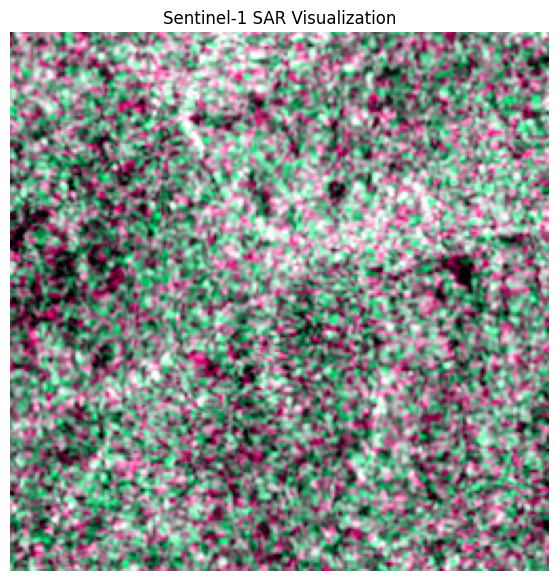

In [89]:
# ============================================================
# PART 10.5 — DISPLAY SENTINEL-1 IMAGE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.imshow(s1_image)
plt.axis("off")
plt.title("Sentinel-1 SAR Visualization")
plt.show()

In [120]:
# ============================================================
# PART 10.6 — SENTINEL-1 VQA TEST
# ============================================================

s1_question = "What can you observe in this Sentinel-1 satellite image?"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": s1_question
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

s1_inputs = processor(
    text=prompt,
    images=[s1_image],
    return_tensors="pt"
)

s1_inputs = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in s1_inputs.items()
}

print("Generating S1 answer...")

with torch.no_grad():
    s1_generated_ids = model.generate(
        **s1_inputs,
        max_new_tokens=100,
        do_sample=False
    )

# Remove prompt tokens
input_length = s1_inputs["input_ids"].shape[1]

s1_generated_tokens = s1_generated_ids[:, input_length:]

s1_answer = processor.batch_decode(
    s1_generated_tokens,
    skip_special_tokens=True
)[0].strip()

print("=" * 60)
print("SENTINEL-1 VQA RESULT")
print("=" * 60)
print("Question:", s1_question)
print("Answer  :", s1_answer)

Generating S1 answer...
SENTINEL-1 VQA RESULT
Question: What can you observe in this Sentinel-1 satellite image?
Answer  : The image is a Sentinel-1 satellite image of a coastal area. The image shows a densely vegetated coastal area with a mix of green and brown vegetation. The vegetation appears to be scattered across the land, with some areas having more vegetation than others. The vegetation is mostly green, indicating that it is healthy and thriving.

The coastal area is bordered by a coastline with a mix of sand and rocky terrain. The sand appears to be relatively flat, with some areas showing signs of erosion or


In [92]:
# ============================================================
# PREPARE S2 IMAGE
# ============================================================

S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

# Load Sentinel-2
s2_data = load_satellite_image(S2_PATH)

# Convert Sentinel-2 to VLM-compatible RGB image
s2_image = prepare_vlm_image(s2_data)

# Convert NumPy → PIL if necessary
if isinstance(s2_image, np.ndarray):
    s2_image = Image.fromarray(
        s2_image.astype(np.uint8)
    ).convert("RGB")

print("S2 image prepared")
print("Type:", type(s2_image))
print("Size:", s2_image.size)

S2 image prepared
Type: <class 'PIL.Image.Image'>
Size: (256, 256)


In [93]:
# ============================================================
# PART 10.7 — LOAD MATCHED S1 + S2 PAIR
# ============================================================

S1_PATH = "/content/sen12ms/s1/ROIs1158_spring_s1_1_p100.tif"
S2_PATH = "/content/sen12ms/s2/ROIs1158_spring_s2_1_p100.tif"

# Load S1
s1_data = load_satellite_image(S1_PATH)

# Load S2
s2_data = load_satellite_image(S2_PATH)

# Convert both to VLM-ready RGB representations
s1_image = s1_to_rgb(S1_PATH)
s2_image = prepare_vlm_image(s2_data)

print("=" * 60)
print("S1 + S2 PAIR LOADED")
print("=" * 60)

print("S1 shape :", s1_data["array"].shape)
print("S2 shape :", s2_data["array"].shape)

print("S1 image:", s1_image.size)
print("S2 image:", s2_image.size)

S1 + S2 PAIR LOADED
S1 shape : (2, 256, 256)
S2 shape : (13, 256, 256)
S1 image: (256, 256)
S2 image: 196608


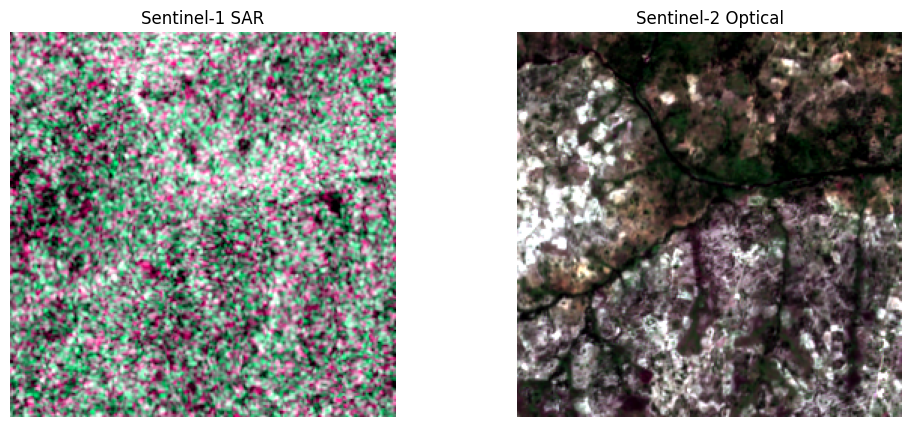

In [94]:
# ============================================================
# PART 10.8 — DISPLAY S1 + S2
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(s1_image)
plt.axis("off")
plt.title("Sentinel-1 SAR")

plt.subplot(1, 2, 2)
plt.imshow(s2_image)
plt.axis("off")
plt.title("Sentinel-2 Optical")

plt.show()

In [121]:
# ============================================================
# PART 10.10 — S1 + S2 CROSS-MODAL VQA
# ============================================================

cross_question = (
    "Compare the Sentinel-1 SAR image and the Sentinel-2 "
    "optical image of the same area. What can you observe "
    "from both images?"
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "image"},
            {
                "type": "text",
                "text": cross_question
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

cross_inputs = processor(
    text=prompt,
    images=[s1_image, s2_image],
    return_tensors="pt"
)

cross_inputs = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in cross_inputs.items()
}

print("Generating cross-modal answer...")

with torch.no_grad():
    generated_ids = model.generate(
        **cross_inputs,
        max_new_tokens=100,
        do_sample=False
    )

input_length = cross_inputs["input_ids"].shape[1]

generated_tokens = generated_ids[:, input_length:]

cross_answer = processor.batch_decode(
    generated_tokens,
    skip_special_tokens=True
)[0].strip()

print("=" * 60)
print("S1 + S2 CROSS-MODAL RESULT")
print("=" * 60)
print("Question:", cross_question)
print("Answer  :", cross_answer)

Generating cross-modal answer...
S1 + S2 CROSS-MODAL RESULT
Question: Compare the Sentinel-1 SAR image and the Sentinel-2 optical image of the same area. What can you observe from both images?
Answer  : The Sentinel-1 SAR image shows a large area of land with a few small islands. The land is covered with vegetation, but the vegetation is sparse. The Sentinel-2 optical image shows a similar area of land with a few small islands. The vegetation is also sparse, but there are more trees and plants.


In [122]:
# ============================================================
# PART 10.11 — SATQUERY MULTIMODAL S1 + S2 (FAST)
# ============================================================

def satquery_multimodal(
    s1_path,
    s2_path,
    question,
    max_new_tokens=150
):
    """
    Cross-modal SatQuery using matched Sentinel-1 + Sentinel-2
    images of the same geographic area.
    """

    # --------------------------------------------------------
    # 1. Load Sentinel-1
    # --------------------------------------------------------
    s1_image = s1_to_rgb(s1_path)

    # Downsample S1 if needed
    if isinstance(s1_image, Image.Image):
        s1_image.thumbnail((MAX_VLM_SIDE, MAX_VLM_SIDE), Image.Resampling.LANCZOS)
    elif isinstance(s1_image, np.ndarray):
        s1_image = _resize_rgb(s1_image.astype(np.uint8))
        s1_image = Image.fromarray(s1_image)

    # --------------------------------------------------------
    # 2. Load Sentinel-2
    # --------------------------------------------------------
    s2_data = load_satellite_image(s2_path)
    s2_image = prepare_vlm_image(s2_data)

    # Ensure PIL RGB
    if isinstance(s2_image, np.ndarray):
        s2_image = Image.fromarray(s2_image.astype(np.uint8))

    s2_image = s2_image.convert("RGB")

    # --------------------------------------------------------
    # 3. Build multimodal prompt
    # --------------------------------------------------------
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "image"},
                {
                    "type": "text",
                    "text": question
                }
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    # --------------------------------------------------------
    # 4. Process S1 + S2 + text
    # --------------------------------------------------------
    inputs = processor(
        text=prompt,
        images=[s1_image, s2_image],
        return_tensors="pt"
    )

    # --------------------------------------------------------
    # 5. Move tensors to device
    # --------------------------------------------------------
    inputs = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    # --------------------------------------------------------
    # 6. Generate answer (fast)
    # --------------------------------------------------------
    print("Generating cross-modal answer...")

    gen_kwargs = dict(FAST_GEN_KWARGS) if "FAST_GEN_KWARGS" in globals() else dict(do_sample=False, use_cache=True)
    gen_kwargs["max_new_tokens"] = max_new_tokens
    pad_id = getattr(processor.tokenizer, "pad_token_id", None)
    if pad_id is not None:
        gen_kwargs["pad_token_id"] = pad_id

    with torch.inference_mode():
        generated_ids = model.generate(**inputs, **gen_kwargs)

    # --------------------------------------------------------
    # 7. Remove prompt tokens
    # --------------------------------------------------------
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = generated_ids[:, input_length:]

    # --------------------------------------------------------
    # 8. Decode
    # --------------------------------------------------------
    answer = processor.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0].strip()

    return {
        "s1_image": s1_image,
        "s2_image": s2_image,
        "question": question,
        "answer": answer
    }


In [97]:
# ============================================================
# PART 10.12 — TEST MULTIMODAL MODEL
# ============================================================

multimodal_result = satquery_multimodal(
    S1_PATH,
    S2_PATH,
    "Compare the Sentinel-1 SAR image and Sentinel-2 optical image. What can you observe from both?"
)

print("=" * 60)
print("SATQUERY MULTIMODAL RESULT")
print("=" * 60)

print("Question:", multimodal_result["question"])
print("Answer  :", multimodal_result["answer"])

Generating cross-modal answer...
SATQUERY MULTIMODAL RESULT
Question: Compare the Sentinel-1 SAR image and Sentinel-2 optical image. What can you observe from both?
Answer  : The Sentinel-1 SAR image shows a large area of land covered in vegetation, while the Sentinel-2 optical image shows a more detailed view of the vegetation and


In [98]:
# ============================================================
# PART 10.14 — END-TO-END S1 + S2 TEST
# ============================================================

result = satquery(
    input_path=S2_PATH,
    query="Compare the Sentinel-1 SAR and Sentinel-2 optical images. What can you observe from both?",
    s1_path=S1_PATH,
    s2_path=S2_PATH,
    max_new_tokens=150
)

print("\n" + "=" * 60)
print("FINAL MULTIMODAL RESULT")
print("=" * 60)

print("Task    :", result["task"])
print("Modality:", result["modality"])
print("Answer  :", result["answer"])

SATQUERY
Query   : Compare the Sentinel-1 SAR and Sentinel-2 optical images. What can you observe from both?
Task    : cross_modal
Modality: S1+S2
Generating cross-modal answer...

FINAL MULTIMODAL RESULT
Task    : multimodal
Modality: S1+S2
Answer  : The Sentinel-1 SAR and Sentinel-2 optical images are similar in many ways. Both images show the same surface of the Earth, but they have different colors and resolution. The Sentinel-1 image is in false color, while the Sentinel-2 image is in true color. The Sentinel-1 image is more detailed, showing the finer details of the surface, while the Sentinel-2 image is


In [99]:
# ============================================================
# PART 11.1E — MULTIMODAL TEST
# ============================================================

result_multi = satquery(
    input_path=S2_PATH,
    s1_path=S1_PATH,
    s2_path=S2_PATH,
    query=(
        "Compare the Sentinel-1 SAR and Sentinel-2 optical "
        "images of the same area. What can you observe?"
    )
)

print("=" * 60)
print("S1 + S2 MULTIMODAL TEST")
print("=" * 60)
print("Answer:", result_multi["answer"])

SATQUERY
Query   : Compare the Sentinel-1 SAR and Sentinel-2 optical images of the same area. What can you observe?
Task    : cross_modal
Modality: S1+S2
Generating cross-modal answer...
S1 + S2 MULTIMODAL TEST
Answer: The Sentinel-1 SAR image shows a more detailed and higher resolution image of the area, while the Sentinel-2 optical image shows a lower resolution and less detailed


In [100]:
# ============================================================
# PART 11.2B — MATCH S1 + S2 BY PATCH ID
# ============================================================

import re
import os

def get_patch_id(path):
    filename = os.path.basename(path)
    match = re.search(r"_p(\d+)\.tif$", filename)

    if match:
        return match.group(1)

    return None


s1_lookup = {
    get_patch_id(path): path
    for path in s1_files
}

s2_lookup = {
    get_patch_id(path): path
    for path in s2_files
}

common_patch_ids = sorted(
    set(s1_lookup.keys()) & set(s2_lookup.keys())
)

pairs = [
    (s1_lookup[patch_id], s2_lookup[patch_id])
    for patch_id in common_patch_ids
]

print("=" * 60)
print("MATCHED S1 + S2 PAIRS")
print("=" * 60)

print("S1 files       :", len(s1_files))
print("S2 files       :", len(s2_files))
print("Matched pairs  :", len(pairs))

for i, (s1_path, s2_path) in enumerate(pairs):

    print(f"\nPair {i + 1}")
    print("S1:", os.path.basename(s1_path))
    print("S2:", os.path.basename(s2_path))

MATCHED S1 + S2 PAIRS
S1 files       : 3
S2 files       : 3
Matched pairs  : 3

Pair 1
S1: ROIs1158_spring_s1_1_p100.tif
S2: ROIs1158_spring_s2_1_p100.tif

Pair 2
S1: ROIs1158_spring_s1_1_p101.tif
S2: ROIs1158_spring_s2_1_p101.tif

Pair 3
S1: ROIs1158_spring_s1_1_p102.tif
S2: ROIs1158_spring_s2_1_p102.tif


In [101]:
# ============================================================
# PART 11.3 — MULTIMODAL EVALUATION
# ============================================================

import time

evaluation_results = []

evaluation_question = (
    "Compare the Sentinel-1 SAR and Sentinel-2 optical "
    "images of the same area. What can you observe?"
)

for i, (s1_path, s2_path) in enumerate(pairs):

    print("\n" + "=" * 60)
    print(f"PAIR {i + 1} / {len(pairs)}")
    print("=" * 60)

    start_time = time.time()

    try:

        result = satquery_multimodal(
            s1_path,
            s2_path,
            evaluation_question,
            max_new_tokens=60
        )

        elapsed = time.time() - start_time

        evaluation_results.append({
            "pair": i + 1,
            "s1": os.path.basename(s1_path),
            "s2": os.path.basename(s2_path),
            "answer": result["answer"],
            "time_seconds": round(elapsed, 2),
            "status": "SUCCESS"
        })

        print("Status :", "SUCCESS")
        print("Time   :", round(elapsed, 2), "seconds")
        print("Answer :", result["answer"])

    except Exception as e:

        elapsed = time.time() - start_time

        evaluation_results.append({
            "pair": i + 1,
            "s1": os.path.basename(s1_path),
            "s2": os.path.basename(s2_path),
            "answer": str(e),
            "time_seconds": round(elapsed, 2),
            "status": "FAILED"
        })

        print("Status :", "FAILED")
        print("Error  :", e)


PAIR 1 / 3
Generating cross-modal answer...
Status : SUCCESS
Time   : 5.04 seconds
Answer : The Sentinel-1 SAR image shows a more detailed and higher resolution image of the area, while the Sentinel-2 optical image shows a lower resolution and less detailed image. The Sentinel-1 image shows a more complex and detailed surface topography, while the Sentinel-2 image shows a more simplified and less

PAIR 2 / 3
Generating cross-modal answer...
Status : SUCCESS
Time   : 4.56 seconds
Answer : The Sentinel-1 SAR image shows a more detailed and higher resolution of the area, while the Sentinel-2 optical image shows a lower resolution and less detail.

PAIR 3 / 3
Generating cross-modal answer...
Status : SUCCESS
Time   : 2.87 seconds
Answer : The Sentinel-1 SAR image shows a more detailed and higher resolution of the area, while the Sentinel-2 optical image shows a lower resolution and less detail.


In [102]:
# ============================================================
# PART 11.4 — EVALUATION SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("MULTIMODAL EVALUATION SUMMARY")
print("=" * 60)

successful = sum(
    r["status"] == "SUCCESS"
    for r in evaluation_results
)

failed = len(evaluation_results) - successful

print("Total pairs :", len(evaluation_results))
print("Successful  :", successful)
print("Failed      :", failed)

for r in evaluation_results:

    print(
        f"\nPair {r['pair']} | "
        f"{r['status']} | "
        f"{r['time_seconds']} sec"
    )

    print("Answer:", r["answer"])


MULTIMODAL EVALUATION SUMMARY
Total pairs : 3
Successful  : 3
Failed      : 0

Pair 1 | SUCCESS | 5.04 sec
Answer: The Sentinel-1 SAR image shows a more detailed and higher resolution image of the area, while the Sentinel-2 optical image shows a lower resolution and less detailed image. The Sentinel-1 image shows a more complex and detailed surface topography, while the Sentinel-2 image shows a more simplified and less

Pair 2 | SUCCESS | 4.56 sec
Answer: The Sentinel-1 SAR image shows a more detailed and higher resolution of the area, while the Sentinel-2 optical image shows a lower resolution and less detail.

Pair 3 | SUCCESS | 2.87 sec
Answer: The Sentinel-1 SAR image shows a more detailed and higher resolution of the area, while the Sentinel-2 optical image shows a lower resolution and less detail.


In [103]:
# ============================================================
# PART 11.5 — CHECK INFERENCE DEVICE
# ============================================================

print("=" * 60)
print("MODEL DEVICE CHECK")
print("=" * 60)

print("Device variable :", device)
print("Model device    :", next(model.parameters()).device)

if torch.cuda.is_available():
    print("CUDA available  : YES")
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    print("CUDA available  : NO")

MODEL DEVICE CHECK
Device variable : cuda
Model device    : cuda:0
CUDA available  : YES
GPU             : Tesla T4


In [104]:
# ============================================================
# PART 11.6 — FAST MULTIMODAL INFERENCE TEST
# ============================================================

import time

start_time = time.time()

fast_result = satquery_multimodal(
    S1_PATH,
    S2_PATH,
    "What are the main differences between the Sentinel-1 and Sentinel-2 images?",
    max_new_tokens=25
)

elapsed = time.time() - start_time

print("=" * 60)
print("FAST MULTIMODAL TEST")
print("=" * 60)

print("Time   :", round(elapsed, 2), "seconds")
print("Answer :", fast_result["answer"])

Generating cross-modal answer...
FAST MULTIMODAL TEST
Time   : 2.0 seconds
Answer : The Sentinel-1 and Sentinel-2 images are satellite images of the Earth, but they differ in their resolution, coverage,


In [125]:
# ============================================================
# PART 12.1 — FINAL UNIFIED SATQUERY (FAST)
# ============================================================

def satquery_final(
    query,
    s2_path=None,
    s1_path=None,
    options=None,
    max_new_tokens=None
):
    # Auto token budget by task (shorter = much faster)
    task_token_budget = {
        "vqa": 100,
        "mcq": 100,
        "captioning": 500,
        "grounding": 500,
        "cross_modal": 500,
    }

    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------
    if s1_path is None and s2_path is None:
        raise ValueError(
            "Provide at least an S1 or S2 image."
        )

    # --------------------------------------------------------
    # Routing
    # --------------------------------------------------------
    routing = analyze_query(query)

    task = routing["task"]
    detected_modality = routing["modality"]

    if max_new_tokens is None:
        max_new_tokens = task_token_budget.get(task, 100)

    print("=" * 60)
    print("SATQUERY (FAST)")
    print("=" * 60)

    print("Query   :", query)
    print("Task    :", task)
    print("Modality:", detected_modality)
    print("Tokens  :", max_new_tokens)

    # ========================================================
    # S1 + S2
    # ========================================================
    if s1_path is not None and s2_path is not None:
        result = satquery_multimodal(
            s1_path,
            s2_path,
            query,
            max_new_tokens=max_new_tokens
        )

        return {
            "task": "cross_modal",
            "modality": "S1+S2",
            "answer": result["answer"],
            "image": None
        }

    # ========================================================
    # S2
    # ========================================================
    if s2_path is not None:

        if task == "captioning":
            answer = satquery_caption(
                s2_path,
                max_new_tokens=max_new_tokens
            )
            return {
                "task": "captioning",
                "modality": "S2",
                "answer": answer,
                "image": None
            }

        elif task == "mcq":
            if options is None:
                raise ValueError("MCQ requires options.")

            answer = satquery_mcq(
                s2_path,
                query,
                options,
                max_new_tokens=max_new_tokens
            )
            return {
                "task": "mcq",
                "modality": "S2",
                "answer": answer,
                "image": None
            }

        elif task == "grounding":
            result = satquery_ground(s2_path, query)

            labels = result["labels"]
            scores = result["scores"]
            boxes = result["boxes"]

            if len(labels) == 0:
                answer = "No matching objects detected."
            else:
                detections = []
                for label, score, box in zip(labels, scores, boxes):
                    detections.append(
                        f"{label} "
                        f"(confidence: {float(score):.3f}, "
                        f"box: {box.tolist()})"
                    )
                answer = "\n".join(detections)

            return {
                "task": "grounding",
                "modality": "S2",
                "answer": answer,
                "image": result["image"],
                "boxes": boxes,
                "scores": scores,
                "labels": labels
            }

        else:
            answer = satquery_vqa(
                s2_path,
                query,
                max_new_tokens=max_new_tokens
            )
            return {
                "task": "vqa",
                "modality": "S2",
                "answer": answer,
                "image": None
            }

    # ========================================================
    # S1 ONLY
    # ========================================================
    if s1_path is not None:
        s1_image = s1_to_rgb(s1_path)
        if isinstance(s1_image, Image.Image):
            s1_image.thumbnail((MAX_VLM_SIDE, MAX_VLM_SIDE), Image.Resampling.LANCZOS)
        elif isinstance(s1_image, np.ndarray):
            s1_image = Image.fromarray(_resize_rgb(s1_image.astype(np.uint8)))

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": query
                    }
                ]
            }
        ]

        prompt = processor.apply_chat_template(
            messages,
            add_generation_prompt=True
        )

        inputs = processor(
            text=prompt,
            images=[s1_image],
            return_tensors="pt"
        )

        inputs = {
            k: v.to(device) if torch.is_tensor(v) else v
            for k, v in inputs.items()
        }

        gen_kwargs = dict(FAST_GEN_KWARGS) if "FAST_GEN_KWARGS" in globals() else dict(do_sample=False, use_cache=True)
        gen_kwargs["max_new_tokens"] = max_new_tokens
        pad_id = getattr(processor.tokenizer, "pad_token_id", None)
        if pad_id is not None:
            gen_kwargs["pad_token_id"] = pad_id

        with torch.inference_mode():
            generated_ids = model.generate(**inputs, **gen_kwargs)

        input_length = inputs["input_ids"].shape[1]
        generated_tokens = generated_ids[:, input_length:]

        answer = processor.batch_decode(
            generated_tokens,
            skip_special_tokens=True
        )[0].strip()

        return {
            "task": task,
            "modality": "S1",
            "answer": answer,
            "image": None
        }


In [106]:
result = satquery_final(
    query="Is there water in this satellite image?",
    s2_path=S2_PATH
)

print("\n" + "=" * 60)
print("FINAL SATQUERY RESULT")
print("=" * 60)

print("Task    :", result["task"])
print("Modality:", result["modality"])
print("Answer  :", result["answer"])

SATQUERY (FAST)
Query   : Is there water in this satellite image?
Task    : vqa
Modality: AUTO
Tokens  : 24

FINAL SATQUERY RESULT
Task    : vqa
Modality: S2
Answer  : No, there is no water visible in this satellite image.


In [107]:
# ============================================================
# PART 13.1 — SATQUERY RESULT FORMATTER
# ============================================================

def format_satquery_result(result):

    task = result.get("task", "unknown")
    modality = result.get("modality", "unknown")
    answer = result.get("answer", "")

    print("=" * 60)
    print("SATQUERY RESULT")
    print("=" * 60)

    print("Task    :", task)
    print("Modality:", modality)
    print("Answer  :", answer)

    return result

In [108]:
result = satquery_final(
    query="Is there water in this satellite image?",
    s2_path=S2_PATH
)

format_satquery_result(result)

SATQUERY (FAST)
Query   : Is there water in this satellite image?
Task    : vqa
Modality: AUTO
Tokens  : 24
SATQUERY RESULT
Task    : vqa
Modality: S2
Answer  : No, there is no water visible in this satellite image.


{'task': 'vqa',
 'modality': 'S2',
 'answer': 'No, there is no water visible in this satellite image.',
 'image': None}

In [141]:
pip install reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.3 MB/s eta 0:00:00


In [142]:
# ============================================================
# PDF REPORT GENERATOR
# ============================================================

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    HRFlowable
)
from reportlab.lib.units import mm
from datetime import datetime
import re


def generate_satquery_report(
    query,
    answer,
    task,
    modality,
    s1_used,
    s2_used,
    options=None
):

    timestamp = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    safe_name = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        query.strip()
    )[:40].strip("_")

    pdf_path = (
        f"/content/SatQuery_Report_"
        f"{safe_name or 'Analysis'}.pdf"
    )

    # --------------------------------------------------------
    # PDF document
    # --------------------------------------------------------

    doc = SimpleDocTemplate(
        pdf_path,
        pagesize=A4,
        rightMargin=18 * mm,
        leftMargin=18 * mm,
        topMargin=18 * mm,
        bottomMargin=18 * mm
    )

    styles = getSampleStyleSheet()

    title_style = ParagraphStyle(
        "SatQueryTitle",
        parent=styles["Title"],
        fontSize=22,
        leading=26,
        alignment=TA_CENTER,
        spaceAfter=8
    )

    subtitle_style = ParagraphStyle(
        "SatQuerySubtitle",
        parent=styles["Normal"],
        fontSize=10,
        leading=14,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#64748b"),
        spaceAfter=18
    )

    heading_style = ParagraphStyle(
        "SatQueryHeading",
        parent=styles["Heading2"],
        fontSize=13,
        leading=17,
        spaceBefore=10,
        spaceAfter=8
    )

    body_style = ParagraphStyle(
        "SatQueryBody",
        parent=styles["BodyText"],
        fontSize=10.5,
        leading=16,
        spaceAfter=8
    )

    small_style = ParagraphStyle(
        "SatQuerySmall",
        parent=styles["BodyText"],
        fontSize=8.5,
        leading=12,
        textColor=colors.HexColor("#64748b")
    )

    # --------------------------------------------------------
    # Sensors
    # --------------------------------------------------------

    sensors = []

    if s2_used:
        sensors.append("Sentinel-2 Optical")

    if s1_used:
        sensors.append("Sentinel-1 SAR")

    sensor_text = (
        ", ".join(sensors)
        if sensors
        else "Not specified"
    )

    # --------------------------------------------------------
    # Story
    # --------------------------------------------------------

    story = []

    story.append(
        Paragraph(
            "SatQuery AI",
            title_style
        )
    )

    story.append(
        Paragraph(
            "Multimodal Vision-Language Analysis for Earth Observation",
            subtitle_style
        )
    )

    story.append(
        HRFlowable(
            width="100%",
            thickness=1,
            color=colors.HexColor("#2563eb"),
            spaceAfter=14
        )
    )

    # --------------------------------------------------------
    # Analysis summary
    # --------------------------------------------------------

    story.append(
        Paragraph(
            "Analysis Summary",
            heading_style
        )
    )

    summary_data = [
        ["Generated", timestamp],
        ["Task", task],
        ["Modality", modality],
        ["Sensors Used", sensor_text],
    ]

    summary_table = Table(
        summary_data,
        colWidths=[40 * mm, 125 * mm]
    )

    summary_table.setStyle(
        TableStyle([
            (
                "BACKGROUND",
                (0, 0),
                (0, -1),
                colors.HexColor("#eff6ff")
            ),
            (
                "TEXTCOLOR",
                (0, 0),
                (0, -1),
                colors.HexColor("#1e3a8a")
            ),
            (
                "FONTNAME",
                (0, 0),
                (-1, -1),
                "Helvetica"
            ),
            (
                "FONTNAME",
                (0, 0),
                (0, -1),
                "Helvetica-Bold"
            ),
            (
                "FONTSIZE",
                (0, 0),
                (-1, -1),
                9.5
            ),
            (
                "GRID",
                (0, 0),
                (-1, -1),
                0.5,
                colors.HexColor("#cbd5e1")
            ),
            (
                "VALIGN",
                (0, 0),
                (-1, -1),
                "MIDDLE"
            ),
            (
                "TOPPADDING",
                (0, 0),
                (-1, -1),
                7
            ),
            (
                "BOTTOMPADDING",
                (0, 0),
                (-1, -1),
                7
            )
        ])
    )

    story.append(summary_table)
    story.append(Spacer(1, 12))

    # --------------------------------------------------------
    # Query
    # --------------------------------------------------------

    story.append(
        Paragraph(
            "User Query",
            heading_style
        )
    )

    story.append(
        Paragraph(
            query,
            body_style
        )
    )

    # --------------------------------------------------------
    # MCQ options
    # --------------------------------------------------------

    if options:

        story.append(
            Paragraph(
                "Multiple-Choice Options",
                heading_style
            )
        )

        for key, value in options.items():

            story.append(
                Paragraph(
                    f"<b>{key}.</b> {value}",
                    body_style
                )
            )

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    story.append(
        Paragraph(
            "SatQuery Result",
            heading_style
        )

    )

    # Escape potentially problematic HTML characters
    answer_safe = (
        str(answer)
        .replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
        .replace("\n", "<br/>")
    )

    story.append(
        Paragraph(
            answer_safe,
            body_style
        )
    )

    # --------------------------------------------------------
    # Prototype capabilities
    # --------------------------------------------------------

    story.append(
        Paragraph(
            "Prototype Capabilities",
            heading_style
        )
    )

    capabilities = [
        "Visual Question Answering",
        "Multiple-Choice VQA",
        "Image Captioning",
        "Object Grounding",
        "Sentinel-1 SAR analysis",
        "Sentinel-2 optical analysis",
        "Sentinel-1 + Sentinel-2 multimodal analysis",
    ]

    for capability in capabilities:

        story.append(
            Paragraph(
                f"- {capability}",
                body_style
            )
        )

    # --------------------------------------------------------
    # Note
    # --------------------------------------------------------

    story.append(
        Spacer(1, 8)
    )

    story.append(
        HRFlowable(
            width="100%",
            thickness=0.5,
            color=colors.HexColor("#cbd5e1"),
            spaceBefore=8,
            spaceAfter=8
        )
    )

    story.append(
        Paragraph(
            "This report contains the output generated by "
            "the SatQuery AI prototype. Results are "
            "AI-assisted Earth-observation analysis and "
            "should not be treated as independently "
            "verified geospatial measurements.",
            small_style
        )
    )

    # --------------------------------------------------------
    # Build PDF
    # --------------------------------------------------------

    doc.build(story)

    return pdf_path


# ============================================================
# DOWNLOAD BUTTON
# ============================================================

download_report = gr.DownloadButton(
    label="📄 Download Analysis Report (PDF)",
    variant="primary",
    interactive=True
)

In [145]:
import os
print(os.path.exists("/content/earth.png"))

True


In [109]:
!pip install -q gradio

In [144]:
# ============================================================
# SATQUERY AI — FINAL GRADIO UI + WORKING REPORT DOWNLOAD
# ============================================================

import gradio as gr
import re
import numpy as np
from PIL import Image
import rasterio
from datetime import datetime


# ============================================================
# REPORT GENERATOR
# ============================================================

def generate_satquery_report(
    query,
    answer,
    task,
    modality,
    s1_used,
    s2_used,
    options=None
):

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    safe_name = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        query.strip()
    )[:40].strip("_")

    report_path = (
        f"/content/SatQuery_Report_"
        f"{safe_name or 'Analysis'}.md"
    )

    sensors = []

    if s2_used:
        sensors.append("Sentinel-2 Optical")

    if s1_used:
        sensors.append("Sentinel-1 SAR")

    report = f"""# SatQuery AI — Analysis Report

## Analysis Summary

Generated: {timestamp}

Task: {task}

Modality: {modality}

Sensors Used: {", ".join(sensors)}

---

## User Query

{query}

"""

    if options:
        report += "## Multiple-Choice Options\n\n"

        for key, value in options.items():
            report += f"- **{key}.** {value}\n"

        report += "\n"

    report += f"""---

## SatQuery Result

{answer}

---

## Supported Prototype Capabilities

- Visual Question Answering
- Multiple-Choice VQA
- Image Captioning
- Object Grounding
- Sentinel-1 SAR analysis
- Sentinel-2 optical analysis
- Sentinel-1 + Sentinel-2 multimodal analysis

---

## Note

This report contains the output generated by the SatQuery AI prototype.
Results are AI-assisted Earth-observation analysis.
"""

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report)

    return report_path


# ============================================================
# IMAGE PREVIEW
# ============================================================

def load_raster_preview(file_path, sensor="S2"):

    if not file_path:
        return None, "Waiting for image..."

    try:

        if file_path.lower().endswith((".tif", ".tiff")):

            with rasterio.open(file_path) as src:

                bands = src.count
                h = src.height
                w = src.width
                crs_str = (
                    str(src.crs)
                    if src.crs
                    else "Not available"
                )

                arr = src.read().astype(np.float32)

            def norm(x):

                p2, p98 = np.percentile(x, (2, 98))

                if p98 <= p2:
                    return np.zeros_like(x)

                return np.clip(
                    (x - p2) / (p98 - p2),
                    0,
                    1
                )

            # Sentinel-1
            if sensor == "S1" and arr.shape[0] >= 2:

                b1 = norm(arr[0])
                b2 = norm(arr[1])

                rgb = np.stack(
                    [
                        b1,
                        b2,
                        (b1 + b2) / 2
                    ],
                    axis=-1
                )

                img = Image.fromarray(
                    (rgb * 255).astype(np.uint8)
                ).convert("RGB")

            # Sentinel-2
            elif sensor == "S2" and arr.shape[0] >= 4:

                blue = norm(arr[1])
                green = norm(arr[2])
                red = norm(arr[3])

                rgb = np.stack(
                    [
                        red,
                        green,
                        blue
                    ],
                    axis=-1
                )

                img = Image.fromarray(
                    (rgb * 255).astype(np.uint8)
                ).convert("RGB")

            # Generic TIFF
            else:

                read_count = min(arr.shape[0], 3)
                preview = arr[:read_count]

                p2, p98 = np.percentile(
                    preview,
                    (2, 98)
                )

                if p98 > p2:

                    preview = np.clip(
                        (preview - p2) /
                        (p98 - p2) * 255,
                        0,
                        255
                    )

                else:

                    preview = np.zeros_like(
                        preview
                    )

                preview = preview.astype(np.uint8)

                if read_count == 1:

                    img = Image.fromarray(
                        preview[0]
                    ).convert("RGB")

                else:

                    img = Image.fromarray(
                        np.transpose(
                            preview,
                            (1, 2, 0)
                        )
                    ).convert("RGB")

            meta = (
                f"**Bands:** {bands}  •  "
                f"**Size:** {w} × {h} px  •  "
                f"**CRS:** `{crs_str}`"
            )

            return img, meta

        # PNG / JPG
        img = Image.open(file_path).convert("RGB")

        w, h = img.size

        return img, (
            f"**Format:** RGB  •  "
            f"**Size:** {w} × {h} px"
        )

    except Exception as e:

        return None, f"Preview error: {str(e)}"


# ============================================================
# MCQ PARSER
# ============================================================

def parse_mcq_options(raw_text):

    if not raw_text or not raw_text.strip():
        return None

    options = {}

    for line in raw_text.strip().splitlines():

        line = line.strip()

        match = re.match(
            r"^([A-Za-z])[\.\)\:\-]\s*(.+)$",
            line
        )

        if match:

            options[
                match.group(1).upper()
            ] = match.group(2).strip()

    return options if options else None


# ============================================================
# MAIN SATQUERY FUNCTION
# ============================================================

def execute_satquery(
    s2_file,
    s1_file,
    query_text,
    options_text
):

    if not query_text or not query_text.strip():

        raise gr.Error(
            "Please enter a query."
        )

    if not s2_file and not s1_file:

        raise gr.Error(
            "Upload a Sentinel-1 or Sentinel-2 image."
        )

    options = parse_mcq_options(
        options_text
    )

    try:

        if "satquery_final" not in globals():

            raise gr.Error(
                "SatQuery backend is not loaded."
            )

        # ----------------------------------------------------
        # ACTUAL BACKEND
        # ----------------------------------------------------

        res = satquery_final(
            query=query_text.strip(),
            s2_path=s2_file,
            s1_path=s1_file,
            options=options,
            max_new_tokens=80
        )

        answer = res.get(
            "answer",
            "No answer returned."
        )

        task = res.get(
            "task",
            "Unknown"
        )

        # ----------------------------------------------------
        # Task label
        # ----------------------------------------------------

        if task == "vqa":

            task_label = "Visual Question Answering"

        elif task == "mcq":

            task_label = "Multiple-Choice VQA"

        elif task == "caption":

            task_label = "Image Captioning"

        elif task == "grounding":

            task_label = "Object Grounding"

        else:

            task_label = str(task).replace(
                "_",
                " "
            ).title()

        # ----------------------------------------------------
        # Modality
        # ----------------------------------------------------

        if s1_file and s2_file:

            modality = "Sentinel-1 + Sentinel-2"

        elif s2_file:

            modality = "Sentinel-2 Optical"

        elif s1_file:

            modality = "Sentinel-1 SAR"

        else:

            modality = res.get(
                "modality",
                "Unknown"
            )

        # ----------------------------------------------------
        # Result
        # ----------------------------------------------------

        result_text = (
            "## Analysis Result\n\n"
            + answer
        )

        # ----------------------------------------------------
        # Grounding
        # ----------------------------------------------------

        grounding_image = res.get(
            "image",
            None
        )

        if task != "grounding":
            grounding_image = None

        # ----------------------------------------------------
        # Technical info
        # ----------------------------------------------------

        audit = {
            "task": task,
            "task_label": task_label,
            "modality": modality,
            "sentinel_1_used": bool(s1_file),
            "sentinel_2_used": bool(s2_file),
            "mcq_options": options
        }

        # ----------------------------------------------------
        # Generate report
        # ----------------------------------------------------

        report_file = generate_satquery_report(
            query=query_text.strip(),
            answer=answer,
            task=task_label,
            modality=modality,
            s1_used=bool(s1_file),
            s2_used=bool(s2_file),
            options=options
        )

        return (
            result_text,
            task_label,
            modality,
            grounding_image,
            audit,
            report_file
        )

    except Exception as e:

        raise gr.Error(
            f"SatQuery execution failed: {str(e)}"
        )


# ============================================================
# CSS
# ============================================================

CUSTOM_CSS = """

/* =========================================================
   SATQUERY AI — EARTH BACKGROUND
   ========================================================= */

html,
body {
    background: #020817 !important;
    margin: 0 !important;
}

/* Main page */
.gradio-container {
    position: relative !important;
    max-width: 1450px !important;
    min-height: 100vh !important;

    background-color: #020817 !important;

    color: #ffffff !important;

    overflow: hidden !important;
}

/* =========================================================
   EARTH BACKGROUND
   ========================================================= */

/*
IMPORTANT:
Put earth.png in:
    /content/earth.png


The Earth is intentionally LARGE and subtle.
*/

.gradio-container::before {
    content: "" !important;

    position: fixed !important;

    width: 1000px !important;
    height: 1000px !important;

    right: -220px !important;
    top: 40px !important;

    background-image: url("file=/content/earth.png") !important;
    background-size: contain !important;
    background-repeat: no-repeat !important;
    background-position: center !important;

    opacity: 0.30 !important;

    z-index: 0 !important;

    pointer-events: none !important;
}

/* =========================================================
   DARK GRADIENT OVER EARTH
   ========================================================= */

.gradio-container::after {
    content: "" !important;

    position: fixed !important;
    inset: 0 !important;

    background:
        radial-gradient(
            circle at 78% 38%,
            rgba(20, 80, 150, 0.08),
            rgba(2, 8, 23, 0.55) 55%,
            rgba(2, 8, 23, 0.90) 100%
        ) !important;

    z-index: 0 !important;

    pointer-events: none !important;
}


/* =========================================================
   KEEP ALL UI ABOVE EARTH
   ========================================================= */

.gradio-container > * {
    position: relative !important;
    z-index: 2 !important;
}


/* =========================================================
   TRANSPARENT / GLASS PANELS
   ========================================================= */

.gr-box,
.gr-panel,
.gr-group {
    background: rgba(20, 32, 50, 0.72) !important;

    border: 1px solid rgba(
        120,
        160,
        210,
        0.28
    ) !important;

    backdrop-filter: blur(5px) !important;

    -webkit-backdrop-filter: blur(5px) !important;
}


/* =========================================================
   CAPABILITY CARDS
   ========================================================= */

.capability {
    background: rgba(
        20,
        35,
        55,
        0.55
    ) !important;

    border: 1px solid rgba(
        100,
        150,
        210,
        0.30
    ) !important;

    border-radius: 12px !important;

    padding: 12px !important;

    text-align: center !important;

    backdrop-filter: blur(4px) !important;

    -webkit-backdrop-filter: blur(4px) !important;
}

.capability p,
.capability strong {
    color: #ffffff !important;
}


/* =========================================================
   RESULT CARD
   ========================================================= */

.result-box {
    background: rgba(
        10,
        20,
        35,
        0.65
    ) !important;

    border: 1px solid rgba(
        100,
        150,
        210,
        0.35
    ) !important;

    border-radius: 14px !important;

    backdrop-filter: blur(7px) !important;

    -webkit-backdrop-filter: blur(7px) !important;
}

.result-box * {
    color: #ffffff !important;
}


/* =========================================================
   INPUTS
   ========================================================= */

input,
textarea {
    background: rgba(
        20,
        35,
        55,
        0.78
    ) !important;

    color: #ffffff !important;

    border-color: rgba(
        100,
        140,
        190,
        0.40
    ) !important;
}

input::placeholder,
textarea::placeholder {
    color: #9fb1c7 !important;
}


/* =========================================================
   LABELS
   ========================================================= */

label,
label span {
    color: #ffffff !important;
}


/* =========================================================
   BUTTONS
   ========================================================= */

button.primary {
    background: #2563eb !important;
    color: #ffffff !important;

    border: none !important;
}

button.primary:hover {
    background: #1d4ed8 !important;
}

button.secondary {
    background: rgba(
        30,
        45,
        65,
        0.80
    ) !important;

    color: #ffffff !important;
}


/* =========================================================
   METADATA
   ========================================================= */

.metadata,
.metadata * {
    color: #9fb1c7 !important;
}


/* =========================================================
   UPLOAD AREAS
   ========================================================= */

.upload-container,
.upload-container * {
    color: #ffffff !important;
}


/* =========================================================
   IMAGE AREAS
   ========================================================= */

.image-container {
    background: rgba(
        10,
        20,
        35,
        0.55
    ) !important;

    border-color: rgba(
        100,
        140,
        190,
        0.25
    ) !important;
}


/* =========================================================
   ACCORDIONS
   ========================================================= */

button[aria-expanded] {
    background: rgba(
        20,
        35,
        55,
        0.70
    ) !important;

    color: #ffffff !important;

    border-color: rgba(
        100,
        140,
        190,
        0.30
    ) !important;
}

"""


# ============================================================
# BUILD UI
# ============================================================

with gr.Blocks(
    title="SatQuery AI",
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="slate"
    ),
    css=CUSTOM_CSS
) as demo:

    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.Markdown(
        """
# 🛰️ SatQuery AI

**Multimodal Vision-Language Analysis for Earth Observation**
""",
        elem_classes=["sat-header"]
    )

    # --------------------------------------------------------
    # CAPABILITIES
    # --------------------------------------------------------

    gr.Markdown(
        "### Supported Prototype Capabilities"
    )

    with gr.Row():

        gr.Markdown(
            "🛰️ **Sentinel-1 SAR**",
            elem_classes=["capability"]
        )

        gr.Markdown(
            "🌍 **Sentinel-2 Optical**",
            elem_classes=["capability"]
        )

        gr.Markdown(
            "❓ **Visual QA / MCQ**",
            elem_classes=["capability"]
        )

        gr.Markdown(
            "📝 **Captioning**",
            elem_classes=["capability"]
        )

        gr.Markdown(
            "📍 **Object Grounding**",
            elem_classes=["capability"]
        )

        gr.Markdown(
            "🔗 **S1 + S2 Analysis**",
            elem_classes=["capability"]
        )

    gr.Markdown("---")

    # --------------------------------------------------------
    # MAIN WORKSPACE
    # --------------------------------------------------------

    with gr.Row():

        # ====================================================
        # LEFT
        # ====================================================

        with gr.Column(scale=6):

            gr.Markdown(
                "### 1. Satellite Data"
            )

            with gr.Row():

                # Sentinel-2
                with gr.Column():

                    gr.Markdown(
                        "### 🌍 Sentinel-2"
                    )

                    s2_file = gr.File(
                        label="Optical MSI image",
                        file_types=[
                            ".tif",
                            ".tiff",
                            ".png",
                            ".jpg",
                            ".jpeg"
                        ],
                        type="filepath"
                    )

                    s2_preview = gr.Image(
                        label="Sentinel-2 Preview",
                        type="pil",
                        interactive=False,
                        height=240
                    )

                    s2_meta = gr.Markdown(
                        "No Sentinel-2 image loaded.",
                        elem_classes=["metadata"]
                    )

                # Sentinel-1
                with gr.Column():

                    gr.Markdown(
                        "### 📡 Sentinel-1"
                    )

                    s1_file = gr.File(
                        label="SAR image",
                        file_types=[
                            ".tif",
                            ".tiff",
                            ".png",
                            ".jpg",
                            ".jpeg"
                        ],
                        type="filepath"
                    )

                    s1_preview = gr.Image(
                        label="Sentinel-1 Preview",
                        type="pil",
                        interactive=False,
                        height=240
                    )

                    s1_meta = gr.Markdown(
                        "No Sentinel-1 image loaded.",
                        elem_classes=["metadata"]
                    )

            # =================================================
            # QUERY
            # =================================================

            gr.Markdown(
                "### 2. Natural-Language Query"
            )

            query_box = gr.Textbox(
                label="Ask SatQuery",
                placeholder=(
                    "Example: Locate the trees in this satellite image."
                ),
                lines=3
            )

            preset_radio = gr.Radio(
                label="Quick Queries",
                choices=[
                    "Is there water in this satellite image?",
                    "Describe this satellite image in two complete sentences.",
                    "Locate the trees in this satellite image.",
                    "What type of land cover is visible in this image?"
                ],
                interactive=True
            )

            # =================================================
            # MCQ
            # =================================================

            with gr.Accordion(
                "Multiple-Choice Question (optional)",
                open=False
            ):

                options_box = gr.Textbox(
                    label="Options",
                    placeholder=(
                        "A. Dense forest\n"
                        "B. Urban area\n"
                        "C. Water\n"
                        "D. Barren land"
                    ),
                    lines=4
                )

            with gr.Row():

                clear_btn = gr.ClearButton(
                    components=[
                        s2_file,
                        s1_file,
                        s2_preview,
                        s1_preview,
                        query_box,
                        options_box
                    ],
                    value="Reset"
                )

                run_btn = gr.Button(
                    "🚀 Analyze Scene",
                    variant="primary",
                    scale=2
                )

        # ====================================================
        # RIGHT
        # ====================================================

        with gr.Column(scale=5):

            gr.Markdown(
                "### 3. SatQuery Analysis"
            )

            with gr.Row():

                task_output = gr.Textbox(
                    label="Task",
                    interactive=False
                )

                modality_output = gr.Textbox(
                    label="Modality",
                    interactive=False
                )

            answer_box = gr.Markdown(
                """
### Ready

Upload satellite data and ask a question.
""",
                elem_classes=["result-box"]
            )

            # =================================================
            # WORKING DOWNLOAD BUTTON
            # =================================================

            download_report = gr.DownloadButton(
                label="📄 Download Analysis Report",
                variant="primary",
                interactive=True
            )

            grounding_view = gr.Image(
                label="Spatial Grounding",
                type="pil",
                interactive=False,
                height=320
            )

            gr.Markdown(
                "*Bounding-box visualization appears for object-grounding queries.*",
                elem_classes=["metadata"]
            )

            with gr.Accordion(
                "Technical Output",
                open=False
            ):

                audit_json = gr.JSON(
                    label="Pipeline Information"
                )

    # ========================================================
    # CALLBACKS
    # ========================================================

    s2_file.change(
        fn=lambda x: load_raster_preview(x, "S2"),
        inputs=s2_file,
        outputs=[
            s2_preview,
            s2_meta
        ]
    )

    s1_file.change(
        fn=lambda x: load_raster_preview(x, "S1"),
        inputs=s1_file,
        outputs=[
            s1_preview,
            s1_meta
        ]
    )

    preset_radio.change(
        fn=lambda x: x,
        inputs=preset_radio,
        outputs=query_box
    )

    run_btn.click(
        fn=execute_satquery,
        inputs=[
            s2_file,
            s1_file,
            query_box,
            options_box
        ],
        outputs=[
            answer_box,
            task_output,
            modality_output,
            grounding_view,
            audit_json,
            download_report
        ]
    )


# ============================================================
# LAUNCH
# ============================================================

demo.queue().launch(
    share=True
)

/tmp/ipykernel_1047/1675084697.py:775: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7426e5a384b14f1536.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [146]:
!git config --global user.name "Aditya-hk"
!git config --global user.email "aditya.upadhyaya11@gmail.com"

In [152]:
!git clone https://github.com/Aditya-hk/Final-Prototype-Satquery-AI.git

Cloning into 'Final-Prototype-Satquery-AI'...


In [153]:
%cd /content/Final-Prototype-Satquery-AI

/content/Final-Prototype-Satquery-AI


In [156]:
%cd /content
!git clone https://github.com/Aditya-hk/Final-Prototype-Satquery-AI.git
%cd /content/Final-Prototype-Satquery-AI

/content
fatal: destination path 'Final-Prototype-Satquery-AI' already exists and is not an empty directory.
/content/Final-Prototype-Satquery-AI


In [158]:
!cp "/mnt/data/Final Prototype.ipynb" "./SatQuery_AI.ipynb"

cp: cannot stat '/mnt/data/Final Prototype.ipynb': No such file or directory


In [160]:
%cd /content
!git clone https://github.com/Aditya-hk/Final-Prototype-Satquery-AI.git
%cd /content/Final-Prototype-Satquery-AI
!cp "/mnt/data/Final Prototype.ipynb" "./SatQuery_AI.ipynb"
!git add
!git commit -m "Add final SatQuery AI prototype"
!git push -u origin main

/content
fatal: destination path 'Final-Prototype-Satquery-AI' already exists and is not an empty directory.
/content/Final-Prototype-Satquery-AI
cp: cannot stat '/mnt/data/Final Prototype.ipynb': No such file or directory
Nothing specified, nothing added.
hint: Maybe you wanted to say 'git add .'?
hint: Turn this message off by running
hint: "git config advice.addEmptyPathspec false"
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Aditya-hk/Final-Prototype-Satquery-AI.git'


In [161]:
!pip -q install fastapi uvicorn python-multipart pyngrok

In [162]:
# ============================================================
# SATQUERY API — COLAB BACKEND
# ============================================================

from fastapi import FastAPI, UploadFile, File, Form
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import os
import tempfile
import json
import threading

app = FastAPI(title="SatQuery AI API")

# Allow your external Streamlit frontend to connect
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


@app.get("/")
def root():
    return {
        "status": "online",
        "service": "SatQuery AI",
        "message": "SatQuery backend is running"
    }


@app.post("/analyze")
async def analyze(
    query: str = Form(...),

    s2: UploadFile | None = File(None),
    s1: UploadFile | None = File(None),

    options: str = Form("")
):

    if not query.strip():
        return {
            "success": False,
            "error": "Query is empty"
        }

    if s2 is None and s1 is None:
        return {
            "success": False,
            "error": "No satellite image uploaded"
        }

    temp_paths = []

    try:

        # ====================================================
        # Save uploaded S2
        # ====================================================

        s2_path = None

        if s2 is not None:

            suffix = os.path.splitext(
                s2.filename
            )[1] or ".tif"

            temp = tempfile.NamedTemporaryFile(
                delete=False,
                suffix=suffix
            )

            data = await s2.read()

            temp.write(data)
            temp.close()

            s2_path = temp.name
            temp_paths.append(s2_path)

        # ====================================================
        # Save uploaded S1
        # ====================================================

        s1_path = None

        if s1 is not None:

            suffix = os.path.splitext(
                s1.filename
            )[1] or ".tif"

            temp = tempfile.NamedTemporaryFile(
                delete=False,
                suffix=suffix
            )

            data = await s1.read()

            temp.write(data)
            temp.close()

            s1_path = temp.name
            temp_paths.append(s1_path)

        # ====================================================
        # Parse MCQ
        # ====================================================

        parsed_options = None

        if options.strip():

            parsed_options = {}

            for line in options.strip().splitlines():

                line = line.strip()

                if not line:
                    continue

                parts = line.split(
                    ".",
                    1
                )

                if len(parts) == 2:

                    key = parts[0].strip().upper()
                    value = parts[1].strip()

                    if key:
                        parsed_options[key] = value

        # ====================================================
        # YOUR ACTUAL SATQUERY BACKEND
        # ====================================================

        result = satquery_final(
            query=query.strip(),
            s2_path=s2_path,
            s1_path=s1_path,
            options=parsed_options,
            max_new_tokens=80
        )

        # ====================================================
        # Return clean JSON
        # ====================================================

        response = {
            "success": True,
            "task": result.get("task", "unknown"),
            "modality": result.get(
                "modality",
                "unknown"
            ),
            "answer": result.get(
                "answer",
                ""
            )
        }

        return response

    except Exception as e:

        return {
            "success": False,
            "error": str(e)
        }

    finally:

        for path in temp_paths:

            try:
                os.remove(path)
            except:
                pass


# ============================================================
# RUN API IN BACKGROUND
# ============================================================

def run_api():

    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )


api_thread = threading.Thread(
    target=run_api,
    daemon=True
)

api_thread.start()

print("✅ SatQuery API started on port 8000")

INFO:     Started server process [1047]


✅ SatQuery API started on port 8000


INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [164]:
pip install ngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 26.3 MB/s eta 0:00:00


In [167]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [168]:
import subprocess
import re

process = subprocess.Popen(
    ["/content/cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None

for _ in range(30):
    line = process.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9-]+\.trycloudflare\.com",
            line
        )

        if match:
            public_url = match.group(0)
            break

print("\nSATQUERY API URL:")
print(public_url)

2026-09-11T14:33:15Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-11T14:33:15Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-11T14:33:18Z INF +--------------------------------------------------------------------------------------------+
2026-09-11T14:33:18Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-11T14:33:18Z INF |  https://extension-dublin-champion-pcs.trycloudflare.c